# Data Quality & Exploratory Data Analysis

This notebook assesses the quality and coverage of the collected data:
- **Tweets** scraped from X (Twitter) via Playwright
- **Price snapshots** (1-minute intraday) stored alongside tweets
- **Historical OHLCV prices** downloaded via yfinance

Goal: Identify data gaps, coverage issues, and basic statistics before sentiment analysis.

## 1 — Setup & Data Loading

In [206]:
import sqlite3
import yaml
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Global plot style: clean grid, muted colors, high resolution
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (12, 5)

# Paths to data sources
DATA_DIR = Path("..") / "data"
DB_PATH = DATA_DIR / "webmining.db"           # SQLite DB with tweets + snapshots
PRICES_CSV = DATA_DIR / "raw" / "prices" / "prices.csv"  # Historical OHLCV from yfinance

# ── Optional start-date filter ────────────────────────────────────────────────
# Set to a "YYYY-MM-DD" string to restrict all tweet-based analyses to tweets
# posted on or after that date.  Leave as None to include all tweets.
TWEET_START_DATE: str | None = "2026-01-01"   # e.g. "2025-03-01"
# ─────────────────────────────────────────────────────────────────────────────

# ── Focus tickers from config ─────────────────────────────────────────────────
# Loaded from configs/tickers.yml → focus_tickers.
# Only these tickers will be used in charts and analyses below.
_cfg = yaml.safe_load((Path("..") / "configs" / "tickers.yml").read_text())
FOCUS_TICKERS: list[str] = _cfg.get("focus_tickers", [])
print(f"Focus tickers ({len(FOCUS_TICKERS)}): {FOCUS_TICKERS}")
# ─────────────────────────────────────────────────────────────────────────────

# Load all three SQLite tables into DataFrames
conn = sqlite3.connect(DB_PATH)

tweets = pd.read_sql("SELECT * FROM tweets", conn)            # Tweet metadata + content
snapshots = pd.read_sql("SELECT * FROM tweet_snapshots", conn) # Engagement snapshots (likes, RT)
price_snaps = pd.read_sql("SELECT * FROM price_snapshots", conn) # 1-min intraday prices per tweet

conn.close()

# Load the separately downloaded daily price history (CSV)
prices = pd.read_csv(PRICES_CSV)

# Convert date/time columns from strings to proper datetime objects
tweets["posted_at"] = pd.to_datetime(tweets["posted_at"])
price_snaps["timestamp"] = pd.to_datetime(price_snaps["timestamp"])
prices["Date"] = pd.to_datetime(prices["Date"])

# Apply optional start-date filter to tweets
if TWEET_START_DATE is not None:
    start_ts = pd.Timestamp(TWEET_START_DATE)
    # Make timezone-aware if tweets carry UTC timezone info
    if tweets["posted_at"].dt.tz is not None:
        start_ts = start_ts.tz_localize("UTC")
    tweets = tweets[tweets["posted_at"] >= start_ts].reset_index(drop=True)
    print(f"[Filter] TWEET_START_DATE = {TWEET_START_DATE} → {len(tweets):,} tweets retained")

# Restrict FOCUS_TICKERS to those actually present in the price CSV
FOCUS_TICKERS = [t for t in FOCUS_TICKERS if t in prices["Ticker"].unique()]

# Quick sanity check: row counts for all data sources
print(f"Tweets:           {len(tweets):>6,}")
print(f"Tweet snapshots:  {len(snapshots):>6,}")
print(f"Price snapshots:  {len(price_snaps):>6,}")
print(f"Prices (CSV):     {len(prices):>6,}")


Focus tickers (13): ['BP', 'XOM', 'SHEL', 'TTE', 'E', '6367.T', 'NIBE-B.ST', 'CARR', '6503.T', 'TSLA', 'BYDDY', 'VWAGY', 'HYMTF']
[Filter] TWEET_START_DATE = 2026-01-01 → 5,151 tweets retained
Tweets:            5,151
Tweet snapshots:  12,889
Price snapshots:  73,660
Prices (CSV):     10,280


In [207]:

# ---------------------------------------------------------------------------
# Pre-compute engagement DataFrame from tweet_snapshots.
# Built here (before Section 2.5) so viral flags are available throughout.
# Full velocity analysis and visualisations remain in Section 11.
# ---------------------------------------------------------------------------

snaps = snapshots.copy()
snaps["crawled_at"] = pd.to_datetime(snaps["crawled_at"], utc=True)

first_snaps = (
    snaps.sort_values("crawled_at")
    .groupby("tweet_id")
    .first()
    .rename(columns={"likes": "first_likes", "retweets": "first_retweets",
                     "crawled_at": "first_crawled_at"})
    .reset_index()
)
last_snaps = (
    snaps.sort_values("crawled_at")
    .groupby("tweet_id")
    .last()
    .rename(columns={"likes": "last_likes", "retweets": "last_retweets",
                     "crawled_at": "last_crawled_at"})
    .reset_index()
)
snap_counts = snaps.groupby("tweet_id").size().rename("snap_count").reset_index()

engagement = (
    first_snaps
    .merge(last_snaps, on="tweet_id")
    .merge(snap_counts, on="tweet_id")
)

# Engagement velocity: Δlikes / elapsed minutes between first and last snapshot
engagement["elapsed_min"] = (
    (engagement["last_crawled_at"] - engagement["first_crawled_at"])
    .dt.total_seconds() / 60
)
engagement["velocity_likes_per_min"] = (
    (engagement["last_likes"] - engagement["first_likes"]) / engagement["elapsed_min"]
)
engagement.loc[engagement["elapsed_min"] == 0, "velocity_likes_per_min"] = float("nan")

# Absolute engagement at first snapshot
engagement["total_engagement_first"] = engagement["first_likes"] + engagement["first_retweets"]

# Viral flag: top-5 % by velocity; fall back to absolute engagement if only 1 snapshot
if engagement["velocity_likes_per_min"].notna().any():
    vel_p95 = engagement["velocity_likes_per_min"].quantile(0.95)
    engagement["is_viral"] = engagement["velocity_likes_per_min"] >= vel_p95
    viral_metric = "velocity_likes_per_min"
    viral_label = "Likes / minute (velocity)"
else:
    eng_p95 = engagement["total_engagement_first"].quantile(0.95)
    engagement["is_viral"] = engagement["total_engagement_first"] >= eng_p95
    viral_metric = "total_engagement_first"
    viral_label = "Total engagement at first snapshot (fallback — no multi-snapshot data yet)"

print(f"engagement ready: {len(engagement):,} rows, viral_metric = '{viral_metric}'")


engagement ready: 5,646 rows, viral_metric = 'velocity_likes_per_min'


## 2 — Tweet Data Overview

In [210]:
# High-level tweet statistics: how many have a stock symbol (cashtag)?
n_total = len(tweets)
n_with_symbol = tweets["symbol"].notna().sum()
n_without_symbol = n_total - n_with_symbol

print(f"Total tweets:       {n_total}")
print(f"With cashtag:       {n_with_symbol} ({n_with_symbol/n_total:.1%})")
print(f"Without cashtag:    {n_without_symbol} ({n_without_symbol/n_total:.1%})")
print(f"Unique symbols:     {tweets['symbol'].nunique()}")
print(f"Unique authors:     {tweets['author'].nunique()}")
print(f"Date range:         {tweets['posted_at'].min():%Y-%m-%d} → {tweets['posted_at'].max():%Y-%m-%d}")

Total tweets:       5151
With cashtag:       2359 (45.8%)
Without cashtag:    2792 (54.2%)
Unique symbols:     237
Unique authors:     1582
Date range:         2026-01-01 → 2026-05-18


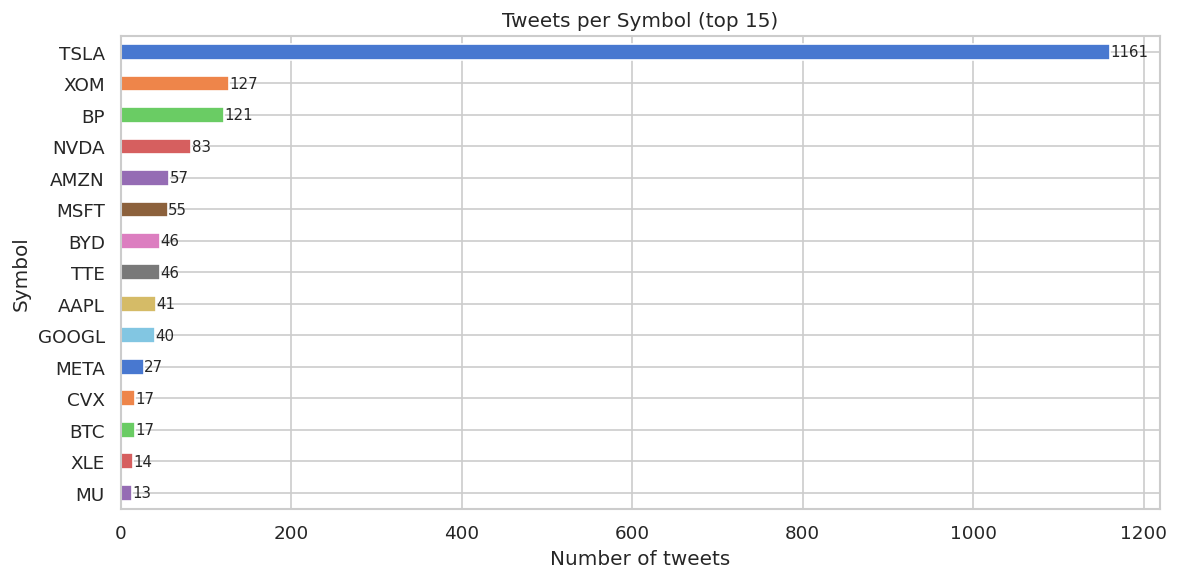

In [211]:
# Horizontal bar chart: which stock symbols appear most often?
# Shows the top 15 symbols by tweet count to identify data concentration.
symbol_counts = tweets["symbol"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 5))
symbol_counts.plot.barh(ax=ax, color=sns.color_palette("muted", len(symbol_counts)))
ax.set_xlabel("Number of tweets")
ax.set_ylabel("Symbol")
ax.set_title("Tweets per Symbol (top 15)")
ax.invert_yaxis()
# Annotate each bar with its count
for i, v in enumerate(symbol_counts.values):
    ax.text(v + 0.5, i, str(v), va="center", fontsize=9)
plt.tight_layout()
plt.show()

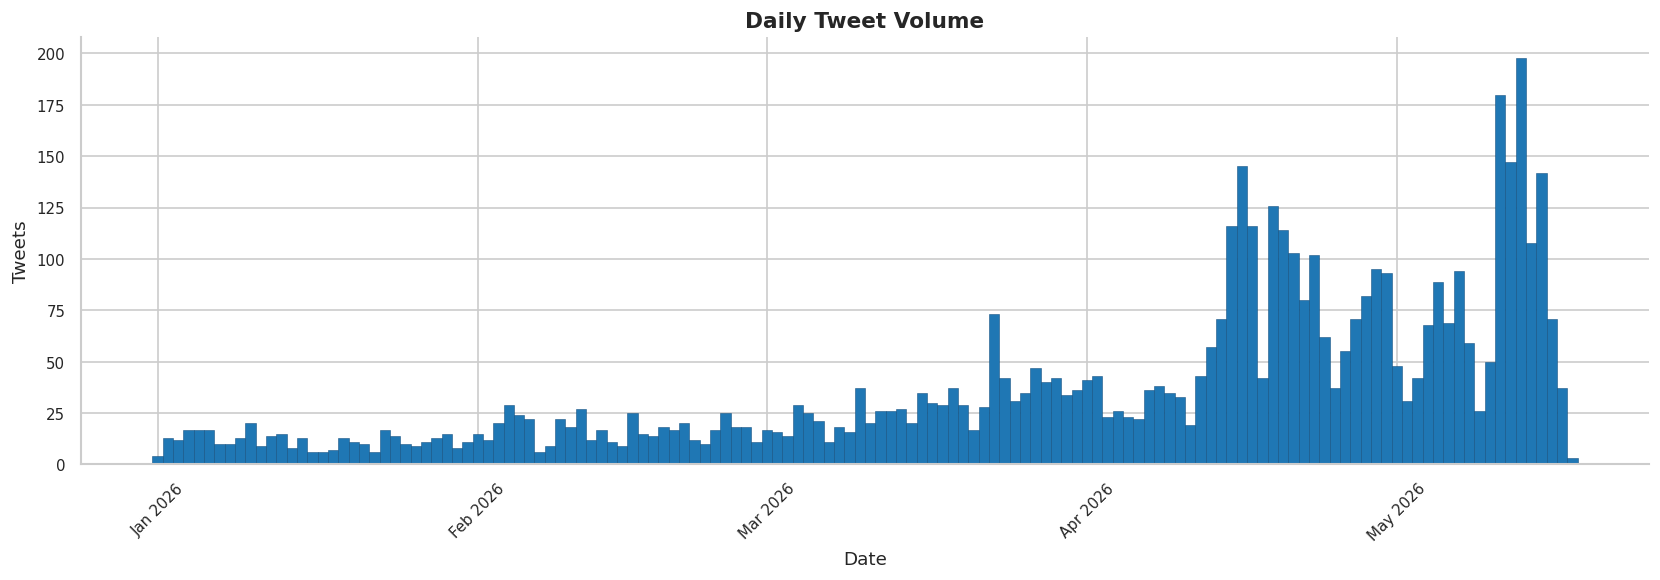

In [212]:
# Daily tweet volume over time — reveals collection gaps and activity spikes.
# Large gaps indicate crawler downtime or session expiry.
tweets["date"] = tweets["posted_at"].dt.date
daily_counts = tweets.groupby("date").size()

# Convert to datetime for proper x-axis formatting
daily_dates = pd.to_datetime(daily_counts.index)

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(daily_dates, daily_counts.values, width=1.0, color="#1f77b4", edgecolor="#0d4a7a", linewidth=0.3)
ax.set_xlabel("Date", fontsize=11)
ax.set_ylabel("Tweets", fontsize=11)
ax.set_title("Daily Tweet Volume", fontsize=13, fontweight="bold")

# Show one tick per month instead of every Monday — much more readable
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_minor_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
ax.tick_params(axis="x", rotation=45, labelsize=9)
ax.tick_params(axis="y", labelsize=9)

# Remove top/right spines for cleaner look
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [213]:
# Merge tweets with their engagement snapshots (likes, retweets)
# to get a combined view of author reach and post performance.
merged = tweets.merge(snapshots, on="tweet_id", how="left")

# Descriptive statistics for follower counts (author influence)
print("Follower count statistics:")
print(tweets["author_followers"].describe().to_string())
print()
# Descriptive statistics for engagement metrics
print("Engagement statistics (likes / retweets):")
print(merged[["likes", "retweets"]].describe().to_string())

Follower count statistics:
count    5.151000e+03
mean     2.027535e+05
std      8.730502e+05
min      1.000000e+02
25%      1.175000e+04
50%      3.720000e+04
75%      1.090000e+05
max      1.390000e+07

Engagement statistics (likes / retweets):
               likes      retweets
count   12394.000000  12394.000000
mean      399.695014     59.651041
std      2787.091399    258.062181
min         0.000000      0.000000
25%       126.000000     10.000000
50%       177.500000     22.000000
75%       323.000000     48.000000
max    158000.000000  10000.000000


### 2.1 — Duplicate & Empty Text Check

In [214]:
# Data quality check: detect duplicate and empty tweets.
# - Duplicate tweet_ids would indicate a crawler bug (same tweet stored twice).
# - Duplicate content may be bots or copy-paste posts.
# - Empty content means the text couldn't be extracted.
n_dup_id = tweets['tweet_id'].duplicated().sum()
n_dup_content = tweets['content'].duplicated().sum()
n_empty = tweets['content'].isna().sum() + (tweets['content'].str.strip() == '').sum()

print(f"Duplicate tweet_ids:    {n_dup_id}")
print(f"Duplicate content:      {n_dup_content}")
print(f"Empty / NaN content:    {n_empty}")

# If duplicates exist, show the most frequently repeated text
if n_dup_content > 0:
    print(f"\nMost repeated content (top 5):")
    dup_content = tweets[tweets['content'].duplicated(keep=False)]
    print(dup_content['content'].value_counts().head(5).to_string())

Duplicate tweet_ids:    0
Duplicate content:      87
Empty / NaN content:    0

Most repeated content (top 5):
content
We are launching Baby \n$Pippin\n\n\npre-sale Started!\n\nTo participate in the send SOL To this address\n\nBKQcgUD2R2PPc9uw25xnCMKVoN3Fa7H3zc8Nfbsg58EG\n\nMin: 1 SOL\n\nMax: 100 SOL\n\nThe tokens will be automatically sent to your wallet. \n\n\n$bp                                           14
We, the \n$WAR\n team, are having a big launch!\n\nThis WW3\n\npre-sale Started\n\nTo participate in the send SOL To this address\n\nBKQcgUD2R2PPc9uw25xnCMKVoN3Fa7H3zc8Nfbsg58EG\n\nMin 1 SOL\n\nMax 100 SOL\n\nThe tokens will be automatically sent to your wallet\n\n\n$bp                       7
$ZETA\n (Zeta Global) #earnings are out:                                                                                                                                                                                                                                                           

### 2.2 — Language Detection

Detected languages (23 total):
lang
en    4910
de      66
fr      32
ja      28
af      21
nl      15
sv      11
et      11
no       9
da       6

English share: 95.3%


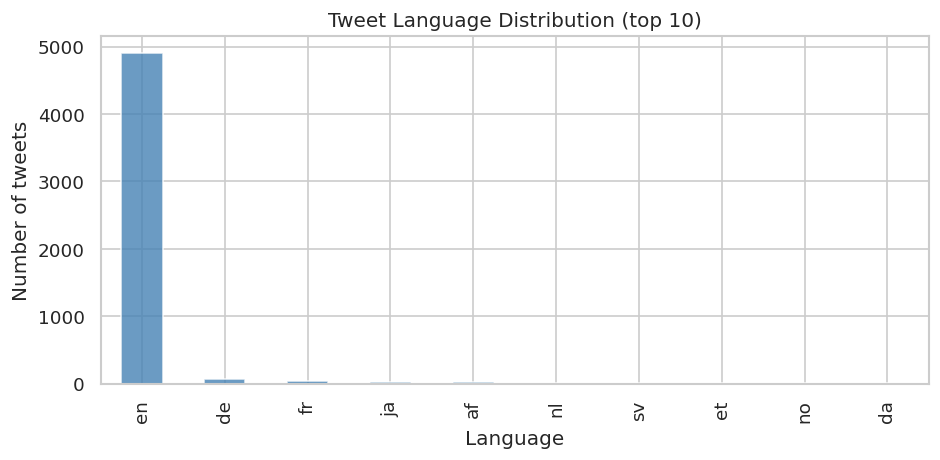

In [215]:
# Detect the language of each tweet using the langdetect library.
# Important for filtering: sentiment models typically expect English text.
# A high non-English share would require multilingual models or filtering.
from langdetect import detect, LangDetectException
from langdetect import DetectorFactory
DetectorFactory.seed = 42  # Fixed seed for reproducible language detection

def safe_detect(text: str) -> str:
    """Detect language, return 'unknown' on failure (e.g. NaN, very short text)."""
    try:
        return detect(text)
    except (LangDetectException, TypeError):
        return "unknown"

# Apply language detection to every tweet
tweets["lang"] = tweets["content"].apply(safe_detect)

# Show distribution of detected languages
lang_counts = tweets["lang"].value_counts()
print(f"Detected languages ({len(lang_counts)} total):")
print(lang_counts.head(10).to_string())
print(f"\nEnglish share: {(tweets['lang'] == 'en').mean():.1%}")

# Bar chart of top 10 languages
fig, ax = plt.subplots(figsize=(8, 4))
lang_counts.head(10).plot.bar(ax=ax, color="steelblue", alpha=0.8)
ax.set_xlabel("Language")
ax.set_ylabel("Number of tweets")
ax.set_title("Tweet Language Distribution (top 10)")
plt.tight_layout()
plt.show()

### 2.3 — Engagement Distribution: Viral vs. Normal

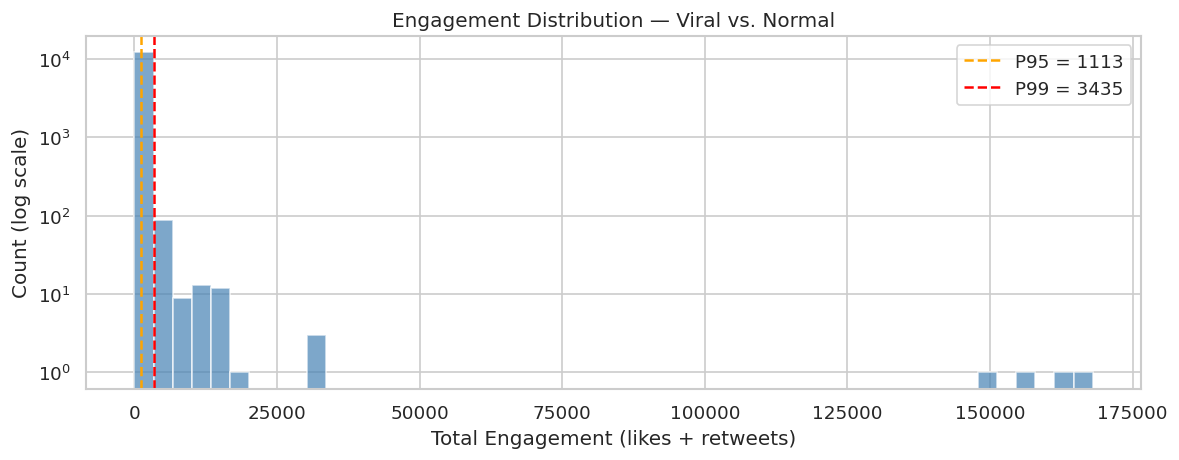

Viral threshold (P95): 1113
Viral tweets (≥P95):   621 (5.0%)
P99 threshold:         3435


In [216]:
# Analyze the engagement distribution to separate "viral" from "normal" tweets.
# Total engagement = likes + retweets. A small fraction of tweets drives most engagement.
# We use P95 as the viral threshold and P99 for extreme outliers.
merged["total_engagement"] = merged["likes"].fillna(0) + merged["retweets"].fillna(0)

p95 = merged["total_engagement"].quantile(0.95)
p99 = merged["total_engagement"].quantile(0.99)

# Histogram with log-scale y-axis (engagement is heavily right-skewed)
fig, ax = plt.subplots(figsize=(10, 4))
merged["total_engagement"].clip(lower=0).hist(
    bins=50, ax=ax, color="steelblue", alpha=0.7, log=True
)
# Mark the P95 and P99 thresholds as vertical lines
ax.axvline(p95, color="orange", linestyle="--", linewidth=1.5, label=f"P95 = {p95:.0f}")
ax.axvline(p99, color="red", linestyle="--", linewidth=1.5, label=f"P99 = {p99:.0f}")
ax.set_xlabel("Total Engagement (likes + retweets)")
ax.set_ylabel("Count (log scale)")
ax.set_title("Engagement Distribution — Viral vs. Normal")
ax.legend()
plt.tight_layout()
plt.show()

# Summary numbers
n_viral = (merged["total_engagement"] >= p95).sum()
print(f"Viral threshold (P95): {p95:.0f}")
print(f"Viral tweets (≥P95):   {n_viral} ({n_viral/len(merged):.1%})")
print(f"P99 threshold:         {p99:.0f}")

### 2.4 — Tweet Content Analysis

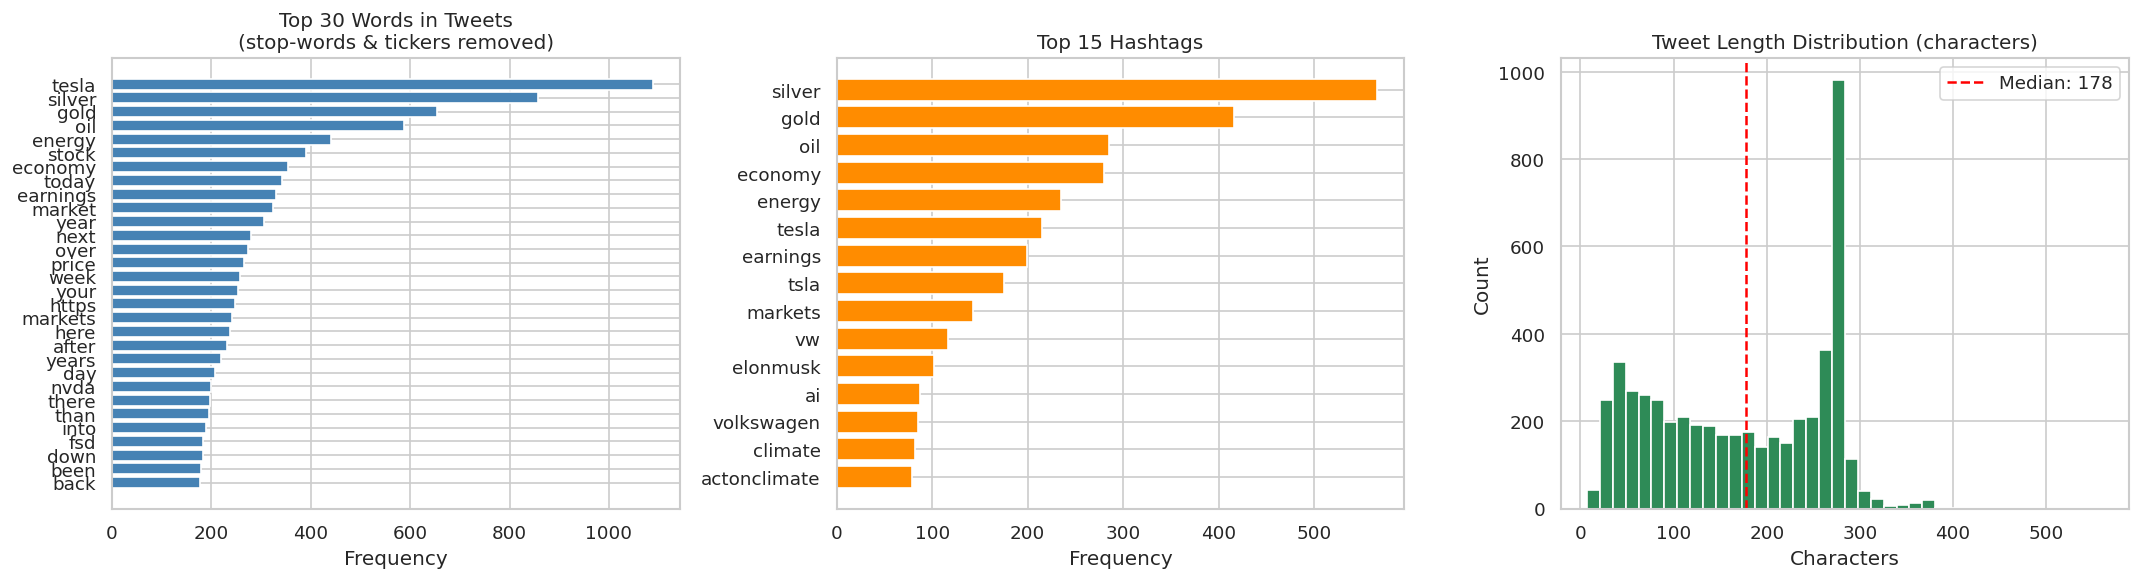

Vocabulary size (after filtering): 13,976 unique words


In [217]:
import re
from collections import Counter

# ---------------------------------------------------------------------------
# 2.4a — Top words in tweet content (stop-word and ticker filtered)
# ---------------------------------------------------------------------------
STOPWORDS = {
    "the","a","an","is","in","it","of","to","and","or","for","on","at","by",
    "this","that","are","was","be","with","from","as","have","has","had",
    "will","would","could","should","not","but","so","if","we","i","you","he",
    "she","they","my","his","her","our","its","what","how","amp","rt","via",
    "just","like","get","got","can","do","dont","going","now","new","all",
    "more","time","up","out","one","when","about","no","–","&","—",
}
# also filter out ticker symbols themselves
ticker_words = {t.lower().replace(".","").replace("-","") for t in FOCUS_TICKERS}
STOPWORDS |= ticker_words

def _tokenize(text: str) -> list[str]:
    tokens = re.findall(r"[a-zA-Z]{3,}", str(text).lower())
    return [t for t in tokens if t not in STOPWORDS]

all_words = Counter()
for content in tweets["content"].dropna():
    all_words.update(_tokenize(content))

top_words = pd.DataFrame(all_words.most_common(30), columns=["word", "count"])

# ---------------------------------------------------------------------------
# 2.4b — Top hashtags
# ---------------------------------------------------------------------------
hashtag_counts: Counter = Counter()
for content in tweets["content"].dropna():
    for tag in re.findall(r"#(\w+)", str(content).lower()):
        hashtag_counts[tag] += 1

top_hashtags = pd.DataFrame(hashtag_counts.most_common(15), columns=["hashtag", "count"])

# ---------------------------------------------------------------------------
# 2.4c — Tweet length distribution
# ---------------------------------------------------------------------------
tweet_lengths = tweets["content"].dropna().str.len()

# ---------------------------------------------------------------------------
# Plot
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Top words
axes[0].barh(top_words["word"][::-1], top_words["count"][::-1], color="steelblue")
axes[0].set_title("Top 30 Words in Tweets\n(stop-words & tickers removed)")
axes[0].set_xlabel("Frequency")

# Top hashtags
if not top_hashtags.empty:
    axes[1].barh(top_hashtags["hashtag"][::-1], top_hashtags["count"][::-1], color="darkorange")
    axes[1].set_title("Top 15 Hashtags")
    axes[1].set_xlabel("Frequency")
else:
    axes[1].text(0.5, 0.5, "No hashtags found", ha="center", va="center", transform=axes[1].transAxes)
    axes[1].set_title("Top 15 Hashtags")

# Tweet length histogram
axes[2].hist(tweet_lengths, bins=40, color="seagreen", edgecolor="white")
axes[2].axvline(tweet_lengths.median(), color="red", linestyle="--", label=f"Median: {tweet_lengths.median():.0f}")
axes[2].set_title("Tweet Length Distribution (characters)")
axes[2].set_xlabel("Characters")
axes[2].set_ylabel("Count")
axes[2].legend()

plt.tight_layout()
plt.show()
print(f"Vocabulary size (after filtering): {len(all_words):,} unique words")

### 2.5 — Focus Ticker Tweet Coverage

In [208]:

import re as _re

# ---------------------------------------------------------------------------
# TICKER_META: maps each FOCUS_TICKER to how it actually appears in the DB.
#
# Two bugs exist without this mapping:
#
#  Bug 1 – Symbol aliasing:
#    extract_cashtag() stores the raw cashtag from the tweet text.
#    e.g. $BYD → symbol="BYD", $VOW → symbol="VOW", $HYUN → symbol="HYUN",
#    $ENI → symbol="ENI".  FOCUS_TICKERS uses yfinance symbols (BYDDY, VWAGY,
#    HYMTF, E) which NEVER appear in the symbol column → always 0 matches.
#
#  Bug 2 – NULL-symbol tweets:
#    ~54 % of tweets were collected via company-name hashtag queries
#    (#Shell, #Volkswagen, #BYD …).  extract_cashtag() only matches $TICKER
#    patterns → symbol = NULL for those tweets, even though the tweet is
#    clearly about a focus company.
#
# Fix: two-pass lookup per ticker
#   pass 1 – symbol_aliases : match rows where symbol IN aliases
#   pass 2 – keyword_re     : match content of remaining (NULL-symbol) tweets
#
# Multilingual note:
#   The crawler now also collects tweets in FR (TTE), IT (Eni), SV/DE (NIBE),
#   JA (Daikin, Mitsubishi Electric), and DE (Volkswagen).  keyword_re patterns
#   cover the non-English terms where the company name differs.
#   Japanese text has no word boundaries → no \b around Japanese characters.
# ---------------------------------------------------------------------------

TICKER_META: dict[str, dict] = {
    "BP": {
        "symbol_aliases": ["BP"],
        "keyword_re": _re.compile(r"(?i)\b(BP|British.?Petroleum)\b"),
    },
    "XOM": {
        "symbol_aliases": ["XOM"],
        "keyword_re": _re.compile(r"(?i)\b(XOM|ExxonMobil|Exxon)\b"),
    },
    "SHEL": {
        "symbol_aliases": ["SHEL"],
        "keyword_re": _re.compile(r"(?i)\b(SHEL|Shell)\b"),
    },
    "TTE": {
        # TotalEnergies est identique en français / French name is the same
        "symbol_aliases": ["TTE"],
        "keyword_re": _re.compile(r"(?i)\b(TTE|TotalEnergies|Total.?Energies)\b"),
    },
    "E": {
        # ADR ticker is "E"; traders use $ENI; Italian name is "Eni" (same)
        "symbol_aliases": ["ENI", "E"],
        "keyword_re": _re.compile(r"(?i)\$ENI\b|\bEni\b"),
    },
    "6367.T": {
        # Tokyo Stock Exchange — no realistic cashtag on Twitter
        # Japanese: ダイキン (Daikin in katakana) — no \b needed in Japanese text
        "symbol_aliases": [],
        "keyword_re": _re.compile(r"(?i)\bDaikin\b|ダイキン"),
    },
    "NIBE-B.ST": {
        # Nasdaq Stockholm — NIBE is the same in Swedish, German, English
        "symbol_aliases": [],
        "keyword_re": _re.compile(r"(?i)\bNIBE\b"),
    },
    "CARR": {
        "symbol_aliases": ["CARR"],
        "keyword_re": _re.compile(r"(?i)\b(CARR|Carrier.?Global|Viessmann)\b"),
    },
    "6503.T": {
        # Tokyo Stock Exchange
        # Japanese: 三菱電機 (Mitsubishi Denki) — no \b needed in Japanese text
        "symbol_aliases": [],
        "keyword_re": _re.compile(r"(?i)\bMitsubishi.?Electric\b|三菱電機"),
    },
    "TSLA": {
        "symbol_aliases": ["TSLA"],
        "keyword_re": _re.compile(r"(?i)\b(TSLA|Tesla)\b"),
    },
    "BYDDY": {
        # $BYD is the common cashtag; BYDDY is the US ADR symbol
        "symbol_aliases": ["BYD", "BYDDY"],
        "keyword_re": _re.compile(r"(?i)\b(BYD|BYDDY)\b"),
    },
    "VWAGY": {
        # $VOW (German symbol) is common; Volkswagen is the same in German/English
        "symbol_aliases": ["VOW", "VWAGY", "VW"],
        "keyword_re": _re.compile(r"(?i)\b(VOW|Volkswagen|\bVW\b)\b"),
    },
    "HYMTF": {
        # $HYUN used more than the OTC symbol HYMTF; Hyundai is the same in Korean/English
        "symbol_aliases": ["HYUN", "HYMTF"],
        "keyword_re": _re.compile(r"(?i)\b(HYUN|Hyundai)\b"),
    },
}

print(f"TICKER_META defined for {len(TICKER_META)} focus tickers.")


TICKER_META defined for 13 focus tickers.


In [209]:

# ---------------------------------------------------------------------------
# Coverage overview for each Focus Ticker.
#
# Three counts per ticker:
#   symbol_n   – tweets where `symbol` is in the ticker's alias list
#                (catches $BYD→BYDDY, $VOW→VWAGY, $ENI→E, etc.)
#   keyword_n  – tweets with NULL symbol whose content matches keyword_re
#                (catches hashtag-collected tweets with no cashtag)
#   total_n    – union (symbol_n + keyword_n, no overlap since keyword
#                pass only runs on NULL-symbol rows)
#
# Colouring:
#   red    – total_n == 0
#   yellow – 0 < total_n < MIN_TWEETS_REQUIRED
#   green  – total_n >= MIN_TWEETS_REQUIRED
# ---------------------------------------------------------------------------

MIN_TWEETS_REQUIRED = 30
price_tickers = set(prices["Ticker"].unique())
viral_ids = set(engagement.loc[engagement["is_viral"], "tweet_id"])

# Separate tweets with a symbol from those without (for keyword pass)
has_symbol_mask = tweets["symbol"].notna()
tweets_no_symbol = tweets[~has_symbol_mask]
content_no_sym = tweets_no_symbol["content"].fillna("")

coverage_rows = []
for ticker in FOCUS_TICKERS:
    meta = TICKER_META.get(ticker, {"symbol_aliases": [ticker], "keyword_re": None})
    aliases = meta["symbol_aliases"]
    kw_re = meta["keyword_re"]

    # Pass 1: symbol alias match
    sym_mask = tweets["symbol"].isin(aliases) if aliases else pd.Series(False, index=tweets.index)
    sym_tweets = tweets[sym_mask]
    symbol_n = len(sym_tweets)

    # Pass 2: keyword match on NULL-symbol rows only (avoid double counting)
    # Use .map(bool(re.search)) to avoid pandas UserWarning about capture groups
    if kw_re is not None:
        kw_mask = content_no_sym.map(lambda x, r=kw_re: bool(r.search(x)))
        kw_tweets = tweets_no_symbol[kw_mask]
        keyword_n = len(kw_tweets)
    else:
        kw_tweets = pd.DataFrame()
        keyword_n = 0

    total_n = symbol_n + keyword_n

    # Viral count across both sets
    all_ids = set(sym_tweets["tweet_id"]) | set(kw_tweets["tweet_id"] if not kw_tweets.empty else [])
    n_viral_t = len(all_ids & viral_ids)

    has_prices = ticker in price_tickers
    coverage_rows.append({
        "Ticker":       ticker,
        "By Symbol":    symbol_n,
        "By Keyword":   keyword_n,
        "Total":        total_n,
        "Viral":        n_viral_t,
        "Price Data":   "✓" if has_prices else "✗",
        "Sufficient":   "✓" if total_n >= MIN_TWEETS_REQUIRED else "✗",
    })

coverage_df = pd.DataFrame(coverage_rows)

def _highlight_coverage(row):
    if row["Total"] == 0:
        color = "background-color: #f8d7da"   # red
    elif row["Total"] < MIN_TWEETS_REQUIRED:
        color = "background-color: #fff3cd"   # yellow
    else:
        color = "background-color: #d4edda"   # green
    return [color] * len(row)

styled_coverage = (
    coverage_df.style
    .apply(_highlight_coverage, axis=1)
    .set_caption(
        f"Focus Ticker Coverage  —  "
        f"green ≥ {MIN_TWEETS_REQUIRED} tweets  |  yellow < {MIN_TWEETS_REQUIRED}  |  red = 0\n"
        f"'By Symbol': cashtag alias match  |  'By Keyword': company-name match on NULL-symbol tweets"
    )
    .set_table_styles([
        {"selector": "caption",
         "props": [("font-weight", "bold"), ("font-size", "13px"), ("white-space", "pre")]}
    ])
)

n_sufficient = (coverage_df["Total"] >= MIN_TWEETS_REQUIRED).sum()
print(f"Focus Tickers with ≥{MIN_TWEETS_REQUIRED} tweets (total):  {n_sufficient} / {len(FOCUS_TICKERS)}")
print(f"Focus Tickers with cashtag only:         {(coverage_df['By Symbol'] >= MIN_TWEETS_REQUIRED).sum()} / {len(FOCUS_TICKERS)}")
print(f"Focus Tickers with price data:           {coverage_df['Price Data'].eq('✓').sum()} / {len(FOCUS_TICKERS)}")
display(styled_coverage)


Focus Tickers with ≥30 tweets (total):  7 / 12
Focus Tickers with cashtag only:         5 / 12
Focus Tickers with price data:           12 / 12


,Ticker,By Symbol,By Keyword,Total,Viral,Price Data,Sufficient
0,BP,121,35,156,2,✓,✓
1,XOM,127,11,138,0,✓,✓
2,SHEL,5,4,9,0,✓,✗
3,TTE,46,13,59,0,✓,✓
4,E,1,8,9,0,✓,✗
5,6367.T,0,21,21,0,✓,✗
6,NIBE-B.ST,0,4,4,0,✓,✗
7,CARR,13,1,14,0,✓,✗
8,6503.T,0,40,40,0,✓,✓
9,TSLA,1161,374,1535,76,✓,✓


### 2.6 — Retweet Detection

Original tweets:  5,151 (100.0%)
Retweets (RT @):  0 (0.0%)


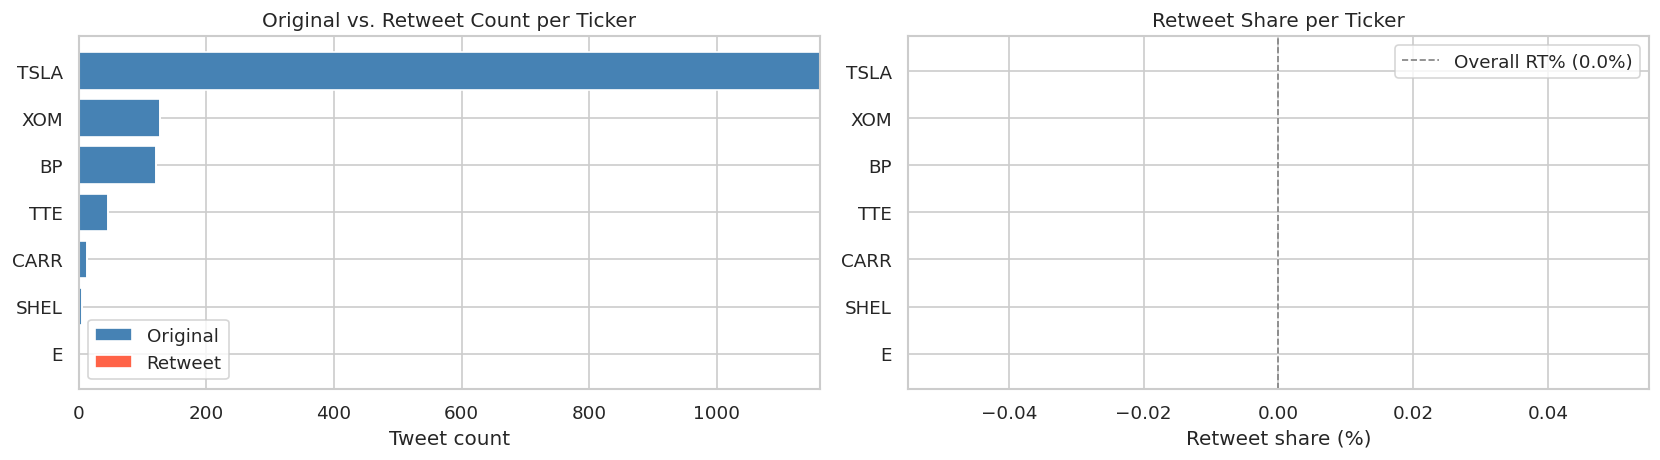


Retweet share per Focus Ticker:
symbol  total  retweets  rt_pct
  TSLA   1161         0     0.0
   XOM    127         0     0.0
    BP    121         0     0.0
   TTE     46         0     0.0
  CARR     13         0     0.0
  SHEL      5         0     0.0
     E      1         0     0.0


In [218]:

# Retweets (tweets starting with "RT @") are copies of other users' content.
# Including them in sentiment analysis would:
#   1. Double-count the original author's opinion.
#   2. Amplify popular opinions disproportionately.
# Here we measure the RT share overall and per Focus Ticker.

tweets["is_retweet"] = tweets["content"].str.strip().str.startswith("RT @").fillna(False)

n_rt = tweets["is_retweet"].sum()
n_orig = (~tweets["is_retweet"]).sum()
rt_share = n_rt / len(tweets)

print(f"Original tweets:  {n_orig:,} ({1 - rt_share:.1%})")
print(f"Retweets (RT @):  {n_rt:,} ({rt_share:.1%})")

# --- per Focus Ticker breakdown ---
rt_per_ticker = (
    tweets[tweets["symbol"].isin(FOCUS_TICKERS)]
    .groupby("symbol")["is_retweet"]
    .agg(total="count", retweets="sum")
    .assign(rt_pct=lambda d: d["retweets"] / d["total"] * 100)
    .sort_values("total", ascending=False)
    .reset_index()
)

# Stacked bar: original vs. retweet count per ticker
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: absolute counts stacked
rt_per_ticker_sorted = rt_per_ticker.sort_values("total", ascending=True)
axes[0].barh(rt_per_ticker_sorted["symbol"], rt_per_ticker_sorted["total"] - rt_per_ticker_sorted["retweets"],
             color="steelblue", label="Original")
axes[0].barh(rt_per_ticker_sorted["symbol"], rt_per_ticker_sorted["retweets"],
             left=rt_per_ticker_sorted["total"] - rt_per_ticker_sorted["retweets"],
             color="tomato", label="Retweet")
axes[0].set_xlabel("Tweet count")
axes[0].set_title("Original vs. Retweet Count per Ticker")
axes[0].legend()

# Right: RT % per ticker
axes[1].barh(rt_per_ticker_sorted["symbol"], rt_per_ticker_sorted["rt_pct"],
             color="tomato", alpha=0.8)
axes[1].axvline(rt_share * 100, color="grey", linestyle="--", linewidth=1,
                label=f"Overall RT% ({rt_share:.1%})")
axes[1].set_xlabel("Retweet share (%)")
axes[1].set_title("Retweet Share per Ticker")
axes[1].legend()

plt.tight_layout()
plt.show()

print("\nRetweet share per Focus Ticker:")
print(rt_per_ticker.to_string(index=False))


### 2.7 — Potential Bot / Spam Accounts

Potential bot accounts flagged:  0
Tweets from bot candidates:      0 (0.0% of all tweets)
Criteria: followers == 0  AND  ≥ 3 tweets in dataset

Top 0 bot-candidate accounts:
Empty DataFrame
Columns: [author, post_count, followers, symbols]
Index: []


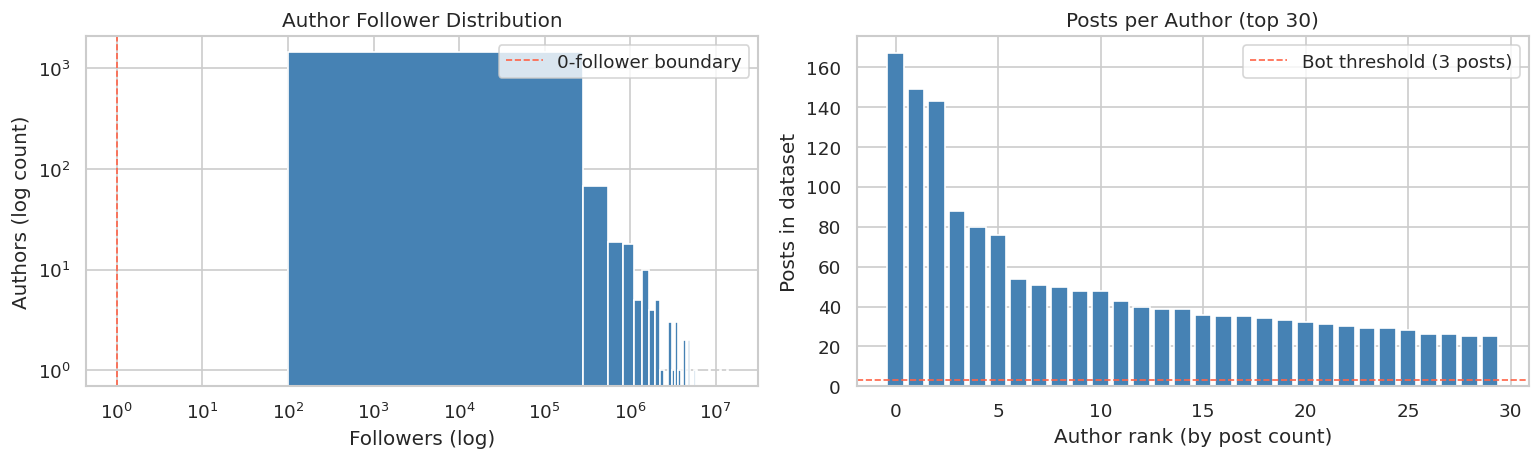

In [219]:

# Heuristic bot / spam detection based on two signals:
#   1. author_followers == 0  → newly created or inactive account
#   2. ≥ BOT_MIN_POSTS tweets from the same account in the dataset
# Accounts matching BOTH criteria are flagged as potential bots/spam.
# Note: this is a conservative heuristic — not all flagged accounts are bots.

BOT_MIN_POSTS = 3   # minimum tweets from the same author to trigger the flag

author_tweet_counts = tweets.groupby("author").size().rename("post_count")
tweets_with_counts = tweets.merge(author_tweet_counts.reset_index(), on="author")

tweets["is_bot_candidate"] = (
    (tweets["author_followers"] == 0)
    & tweets["author"].isin(
        author_tweet_counts[author_tweet_counts >= BOT_MIN_POSTS].index
    )
)

n_bot_candidates = tweets["is_bot_candidate"].sum()
n_bot_accounts = tweets[tweets["is_bot_candidate"]]["author"].nunique()
bot_tweet_share = n_bot_candidates / len(tweets)

print(f"Potential bot accounts flagged:  {n_bot_accounts}")
print(f"Tweets from bot candidates:      {n_bot_candidates} ({bot_tweet_share:.1%} of all tweets)")
print(f"Criteria: followers == 0  AND  ≥ {BOT_MIN_POSTS} tweets in dataset")

# Table: top suspect accounts sorted by post count
suspect_accounts = (
    tweets[tweets["is_bot_candidate"]]
    .groupby("author")
    .agg(
        post_count=("tweet_id", "count"),
        followers=("author_followers", "first"),
        symbols=("symbol", lambda x: ", ".join(sorted(x.dropna().unique()))),
    )
    .sort_values("post_count", ascending=False)
    .head(20)
    .reset_index()
)

print(f"\nTop {len(suspect_accounts)} bot-candidate accounts:")
print(suspect_accounts.to_string(index=False))

# Distribution: follower count for all authors (log scale)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

follower_dist = tweets.drop_duplicates("author")["author_followers"]
axes[0].hist(follower_dist.clip(lower=1), bins=50, color="steelblue", log=True)
axes[0].set_xscale("log")
axes[0].set_xlabel("Followers (log)")
axes[0].set_ylabel("Authors (log count)")
axes[0].set_title("Author Follower Distribution")
axes[0].axvline(1, color="tomato", linestyle="--", linewidth=1, label="0-follower boundary")
axes[0].legend()

# Posts per author — how concentrated is the data?
posts_per_author = author_tweet_counts.sort_values(ascending=False)
axes[1].bar(range(min(30, len(posts_per_author))), posts_per_author.values[:30],
            color="steelblue")
axes[1].axhline(BOT_MIN_POSTS, color="tomato", linestyle="--",
                linewidth=1, label=f"Bot threshold ({BOT_MIN_POSTS} posts)")
axes[1].set_xlabel("Author rank (by post count)")
axes[1].set_ylabel("Posts in dataset")
axes[1].set_title("Posts per Author (top 30)")
axes[1].legend()

plt.tight_layout()
plt.show()


## 3 — Price Snapshot Coverage

In [220]:
# Check how many tweets have associated 1-minute intraday price snapshots.
# These snapshots were fetched during crawling to capture price movement around each tweet.
# Missing price data = tweet was posted outside market hours or the fetcher failed.
tweet_ids_with_prices = price_snaps["tweet_id"].unique()
n_with_prices = tweets["tweet_id"].isin(tweet_ids_with_prices).sum()
n_without_prices = len(tweets) - n_with_prices

print(f"Tweets with price data:    {n_with_prices} ({n_with_prices/len(tweets):.1%})")
print(f"Tweets without price data: {n_without_prices} ({n_without_prices/len(tweets):.1%})")
print(f"Average price snapshots per tweet (where available): "
      f"{price_snaps.groupby('tweet_id').size().mean():.1f}")
print(f"Total price snapshot rows: {len(price_snaps):,}")

Tweets with price data:    723 (14.0%)
Tweets without price data: 4428 (86.0%)
Average price snapshots per tweet (where available): 101.9
Total price snapshot rows: 73,660


In [221]:
# Price snapshot coverage broken down by stock symbol.
# Shows which tickers have the best/worst price data coverage.
# Low coverage means many tweets for that symbol lack price context.
tweets_with_price_flag = tweets.copy()
tweets_with_price_flag["has_price"] = tweets["tweet_id"].isin(tweet_ids_with_prices)
coverage = (
    tweets_with_price_flag[tweets_with_price_flag["symbol"].notna()]
    .groupby("symbol")["has_price"]
    .agg(["sum", "count"])
    .rename(columns={"sum": "with_price", "count": "total"})
    .assign(pct=lambda d: d["with_price"] / d["total"])
    .sort_values("total", ascending=False)
    .head(15)
)
print(coverage.to_string())

        with_price  total       pct
symbol                             
TSLA           451   1161  0.388458
XOM             17    127  0.133858
BP              13    121  0.107438
NVDA            16     83  0.192771
AMZN            22     57  0.385965
MSFT            23     55  0.418182
BYD              0     46  0.000000
TTE              3     46  0.065217
AAPL            13     41  0.317073
GOOGL           22     40  0.550000
META             9     27  0.333333
CVX              2     17  0.117647
BTC              3     17  0.176471
XLE              1     14  0.071429
MU               4     13  0.307692


## 4 — Historical Price Data (CSV) Quality

In [222]:
# Overview of the historical daily price CSV downloaded via yfinance.
# Check for: total rows, tickers present, date range, and missing values (NaNs).
print(f"Rows: {len(prices):,}")
print(f"Tickers: {sorted(prices['Ticker'].unique())}")
print(f"Date range: {prices['Date'].min():%Y-%m-%d} → {prices['Date'].max():%Y-%m-%d}")
print(f"Missing values:\n{prices.isnull().sum().to_string()}")
print()

# How many rows per ticker? Unequal counts may indicate partial downloads.
rows_per_ticker = prices.groupby("Ticker").agg(
    rows=("Date", "count"),
    first_date=("Date", "min"),
    last_date=("Date", "max"),
)
print("Rows per ticker:")
print(rows_per_ticker.to_string())

Rows: 10,280
Tickers: ['6367.T', '6503.T', 'AAPL', 'AMZN', 'BP', 'BYDDY', 'CARR', 'E', 'GOOGL', 'META', 'MSFT', 'NIBE-B.ST', 'NVDA', 'SHEL', 'TSLA', 'TTE', 'VWAGY', 'XOM']
Date range: 2024-01-02 → 2026-04-23
Missing values:
Date         0
Ticker       0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0

Rows per ticker:
           rows first_date  last_date
Ticker                               
6367.T      563 2024-01-04 2026-04-23
6503.T      563 2024-01-04 2026-04-23
AAPL        561 2024-01-02 2026-03-27
AMZN        561 2024-01-02 2026-03-27
BP          579 2024-01-02 2026-04-23
BYDDY       579 2024-01-02 2026-04-23
CARR        579 2024-01-02 2026-04-23
E           579 2024-01-02 2026-04-23
GOOGL       561 2024-01-02 2026-03-27
META        561 2024-01-02 2026-03-27
MSFT        561 2024-01-02 2026-03-27
NIBE-B.ST   577 2024-01-02 2026-04-23
NVDA        561 2024-01-02 2026-03-27
SHEL        579 2024-01-02 2026-04-23
TSLA        579 2024-01-02 202

In [223]:
# Descriptive statistics (mean, std, min, max, quartiles) of Adjusted Close per ticker.
# Helps spot obviously wrong values (e.g. price = 0, extreme outliers).
price_stats = prices.groupby("Ticker")["Adj Close"].describe()
print(price_stats.to_string())

           count          mean          std           min           25%           50%           75%           max
Ticker                                                                                                           
6367.T     563.0  18830.057586  2076.670907  14889.286133  17332.367188  18660.714844  19960.349609  24324.861328
6503.T     563.0   3171.293232  1079.888449   1847.617920   2399.091309   2678.600830   3746.461182   6088.000000
AAPL       561.0    222.963505    30.520590    163.511917    200.390213    224.415833    246.612839    285.922455
AMZN       561.0    203.147986    23.924227    144.570007    183.630005    205.020004    223.809998    254.000000
BP         579.0     32.411532     4.310202     24.657839     29.582266     31.918159     33.969374     47.630001
BYDDY      579.0     12.215564     2.775622      7.099208      9.816664     12.280000     14.100000     19.521166
CARR       579.0     63.430274     7.444650     50.144901     56.929502     62.986584   

### 4.1 — Missing Trading Days

In [224]:
# Compare the dates in our CSV against the official NYSE trading calendar.
# Missing trading days = days when the market was open but we have no price data.
# Uses the exchange_calendars library for accurate holiday/half-day handling.
import exchange_calendars as xcals

# Use only the focus tickers defined in configs/tickers.yml
tickers = FOCUS_TICKERS

# Get all NYSE trading sessions in the date range of our price data
xnys = xcals.get_calendar("XNYS")
price_start = prices["Date"].min()
price_end = prices["Date"].max()
trading_days = xnys.sessions_in_range(price_start, price_end)

print(f"NYSE trading days in range: {len(trading_days)}")

# For each ticker, find which expected trading days are missing from the CSV
missing_per_ticker = {}
for ticker in tickers:
    ticker_dates = set(prices[prices['Ticker'] == ticker]['Date'].dt.normalize())
    missing = sorted(set(trading_days) - ticker_dates)
    missing_per_ticker[ticker] = missing

# Summary table: expected vs. actual trading day count per ticker
missing_df = pd.DataFrame([
    {"Ticker": t, "expected": len(trading_days), "present": len(trading_days) - len(m),
     "missing": len(m), "pct_complete": (len(trading_days) - len(m)) / len(trading_days)}
    for t, m in missing_per_ticker.items()
])
print("\nTrading day completeness per ticker:")
print(missing_df.to_string(index=False))

# Preview the first few missing dates per ticker (if any)
for t, m in missing_per_ticker.items():
    if m:
        preview = [d.strftime('%Y-%m-%d') for d in m[:5]]
        suffix = f' ... (+{len(m)-5} more)' if len(m) > 5 else ''
        print(f"  {t} missing: {', '.join(preview)}{suffix}")


NYSE trading days in range: 579

Trading day completeness per ticker:
   Ticker  expected  present  missing  pct_complete
       BP       579      579        0      1.000000
      XOM       579      579        0      1.000000
     SHEL       579      579        0      1.000000
      TTE       579      579        0      1.000000
        E       579      579        0      1.000000
   6367.T       579      541       38      0.934370
NIBE-B.ST       579      560       19      0.967185
     CARR       579      579        0      1.000000
   6503.T       579      541       38      0.934370
     TSLA       579      579        0      1.000000
    BYDDY       579      579        0      1.000000
    VWAGY       579      579        0      1.000000
  6367.T missing: 2024-01-02, 2024-01-03, 2024-01-08, 2024-02-12, 2024-02-23 ... (+33 more)
  NIBE-B.ST missing: 2024-04-01, 2024-05-01, 2024-05-09, 2024-06-06, 2024-06-21 ... (+14 more)
  6503.T missing: 2024-01-02, 2024-01-03, 2024-01-08, 2024-02-12, 2

### 4.2 — Daily Returns & Outlier Detection

Outlier returns (IQR×3): 82 of 10262

Largest negative returns:
      Date    Ticker   Adj Close  return_pct
2025-01-27      NVDA  118.381210  -16.968170
2025-03-10      TSLA  222.149994  -15.426207
2024-08-05    6503.T 1847.617920  -13.386355
2024-02-16 NIBE-B.ST   57.406441  -13.349158
2026-02-25 NIBE-B.ST   35.099998  -13.054250

Largest positive returns:
      Date Ticker  Adj Close  return_pct
2024-02-22   NVDA  78.490028   16.400880
2025-04-09   NVDA 114.303070   18.722746
2024-02-02   META 471.291534   20.317644
2024-10-24   TSLA 260.480011   21.919035
2025-04-09   TSLA 272.200012   22.689990


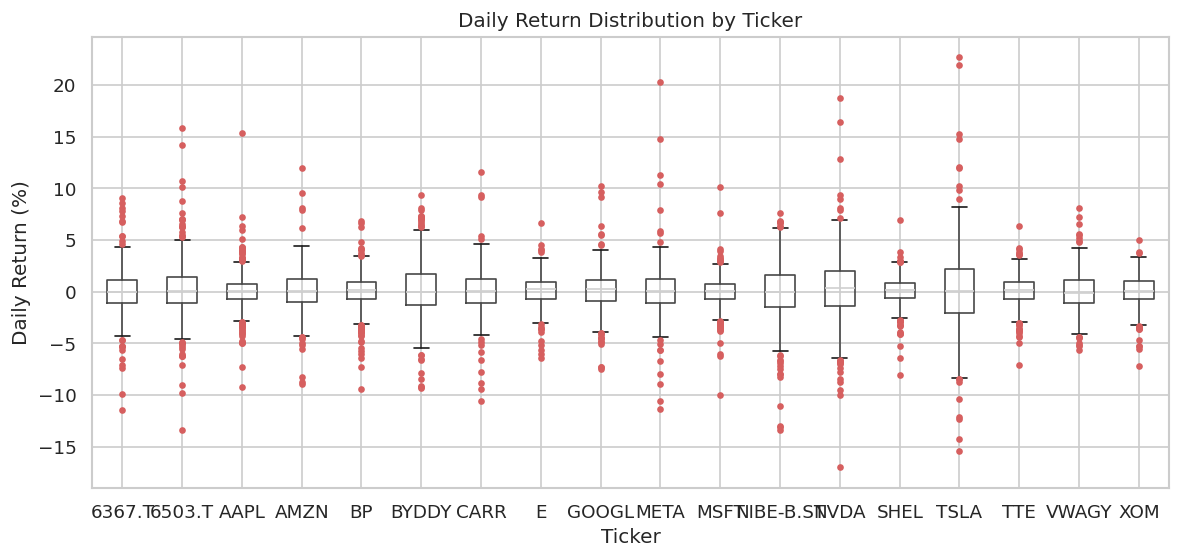

In [225]:
# Calculate daily percentage returns and flag statistical outliers.
# Returns = (price_today / price_yesterday - 1) × 100
# Outlier detection uses IQR × 3 per ticker (conservative threshold).
prices_sorted = prices.sort_values(["Ticker", "Date"])
prices_sorted["return_pct"] = (
    prices_sorted.groupby("Ticker")["Adj Close"].pct_change() * 100
)

# IQR-based outlier detection: values beyond Q1 - 3*IQR or Q3 + 3*IQR
# Using transform() to avoid index alignment issues with groupby().apply()
def iqr_outlier(s):
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    return (s < q1 - 3 * iqr) | (s > q3 + 3 * iqr)

prices_sorted["is_outlier"] = prices_sorted.groupby("Ticker")["return_pct"].transform(iqr_outlier)

n_outliers = prices_sorted["is_outlier"].sum()
print(f"Outlier returns (IQR×3): {n_outliers} of {prices_sorted['return_pct'].notna().sum()}")

# Show the most extreme returns (potential data errors or real market events)
if n_outliers > 0:
    outlier_rows = prices_sorted[prices_sorted["is_outlier"]].sort_values("return_pct")
    print("\nLargest negative returns:")
    print(outlier_rows[["Date", "Ticker", "Adj Close", "return_pct"]].head(5).to_string(index=False))
    print("\nLargest positive returns:")
    print(outlier_rows[["Date", "Ticker", "Adj Close", "return_pct"]].tail(5).to_string(index=False))

# Boxplot comparing daily return distributions across tickers
fig, ax = plt.subplots(figsize=(10, 5))
prices_sorted.boxplot(column="return_pct", by="Ticker", ax=ax, sym="r.")
ax.set_title("Daily Return Distribution by Ticker")
ax.set_xlabel("Ticker")
ax.set_ylabel("Daily Return (%)")
plt.suptitle("")
plt.tight_layout()
plt.show()

### 4.3 — Returns & Rolling Volatility

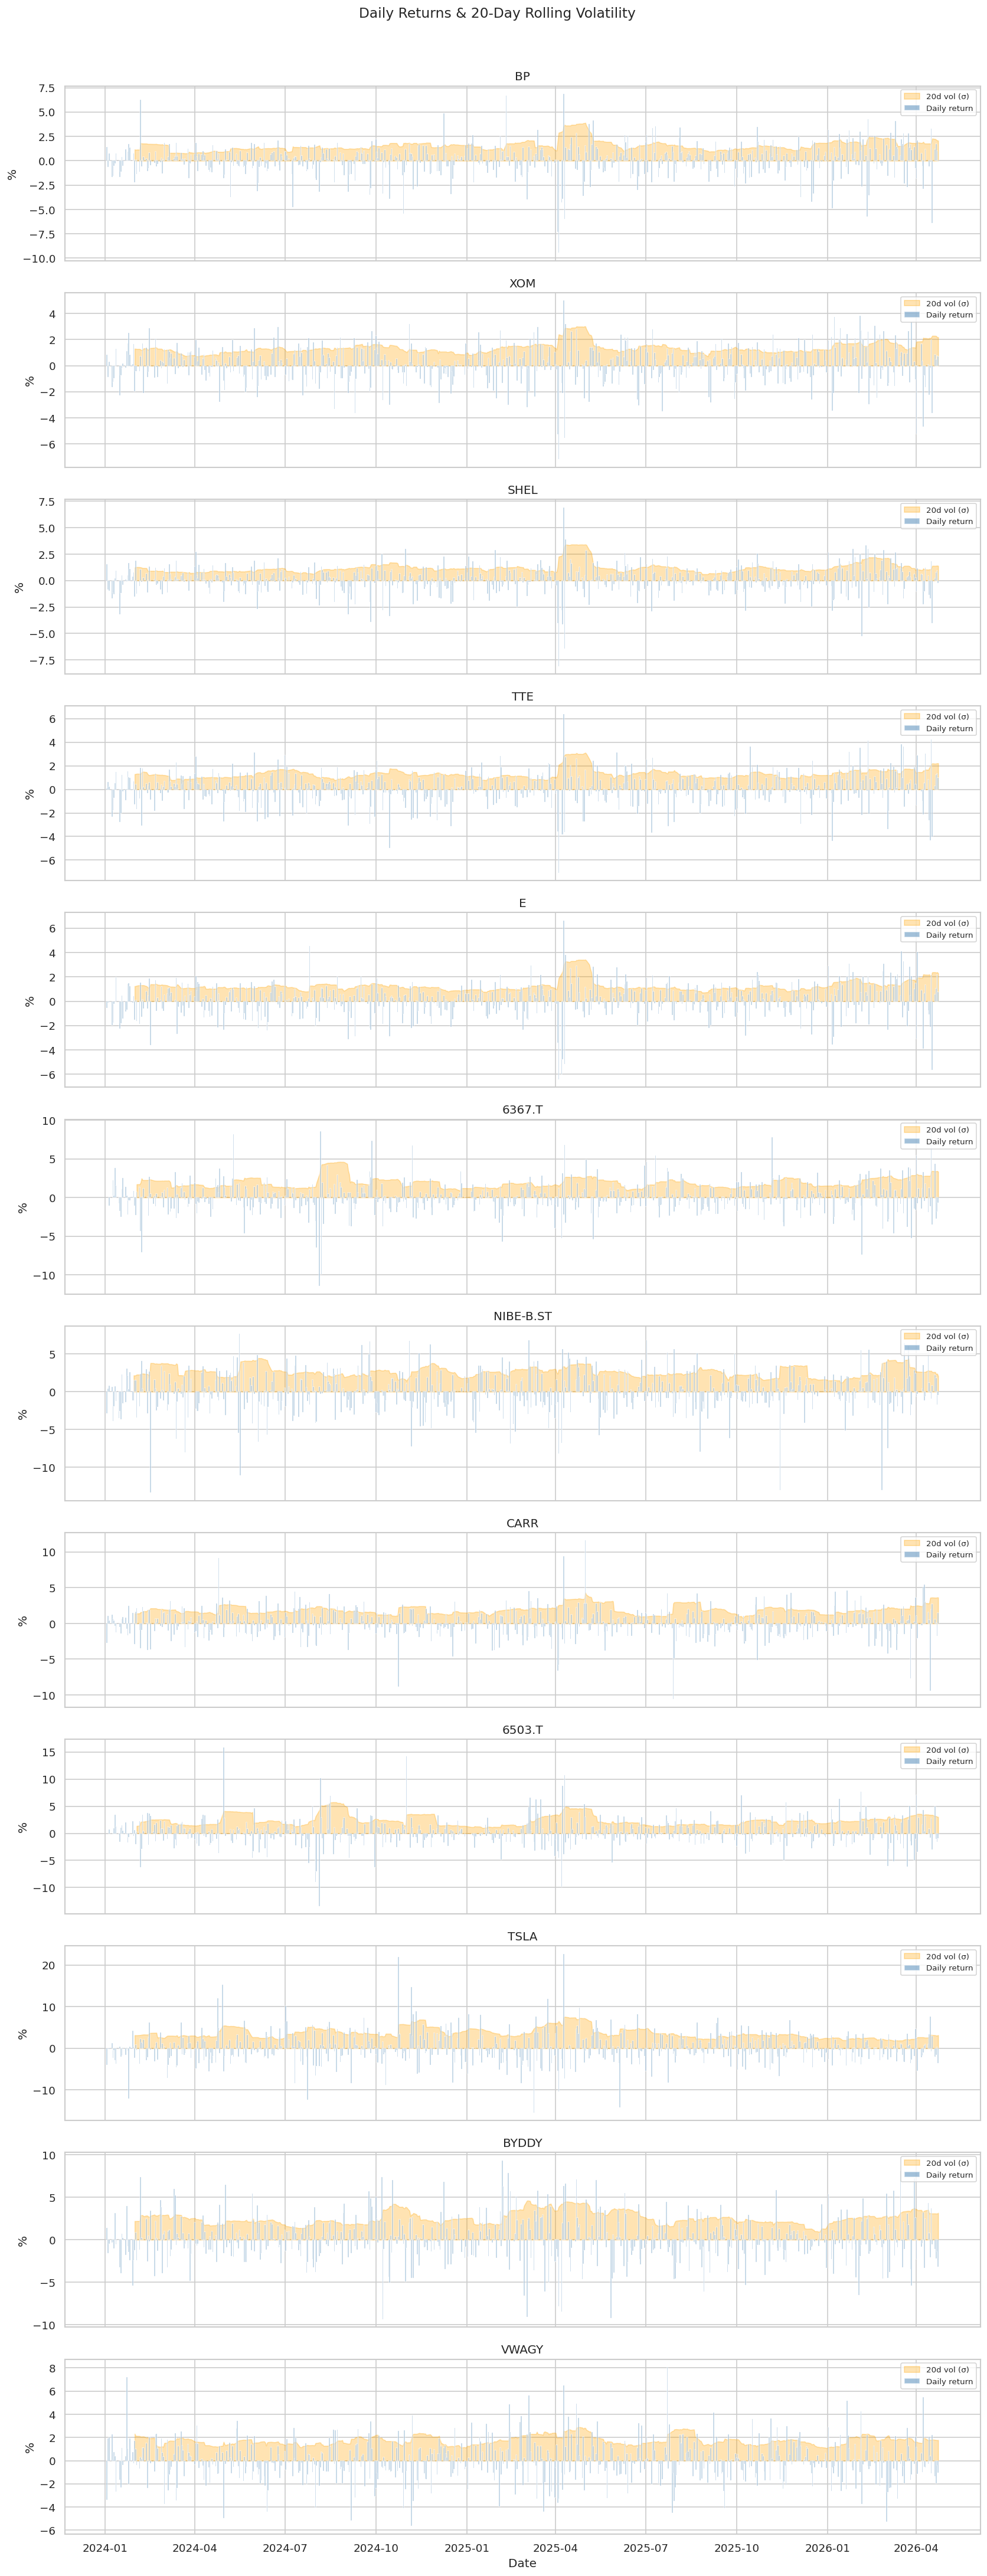

In [226]:
# Plot daily returns (bars) overlaid with 20-day rolling volatility (filled area).
# Rolling volatility = standard deviation of returns over the last 20 trading days.
# High volatility periods may correlate with increased social media activity.
fig, axes = plt.subplots(len(tickers), 1, figsize=(14, 3 * len(tickers)), sharex=True)
if len(tickers) == 1:
    axes = [axes]

for ax, ticker in zip(axes, tickers):
    subset = prices_sorted[prices_sorted["Ticker"] == ticker].sort_values("Date")
    vol_20d = subset["return_pct"].rolling(20).std()

    ax.fill_between(subset["Date"], vol_20d, alpha=0.3, color="orange", label="20d vol (σ)")
    ax.bar(subset["Date"], subset["return_pct"], width=1, alpha=0.5, color="steelblue", label="Daily return")
    ax.set_ylabel("%")
    ax.set_title(ticker)
    ax.legend(loc="upper right", fontsize=8)

axes[-1].set_xlabel("Date")
fig.suptitle("Daily Returns & 20-Day Rolling Volatility", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 4.4 — Cross-Ticker Return Correlations

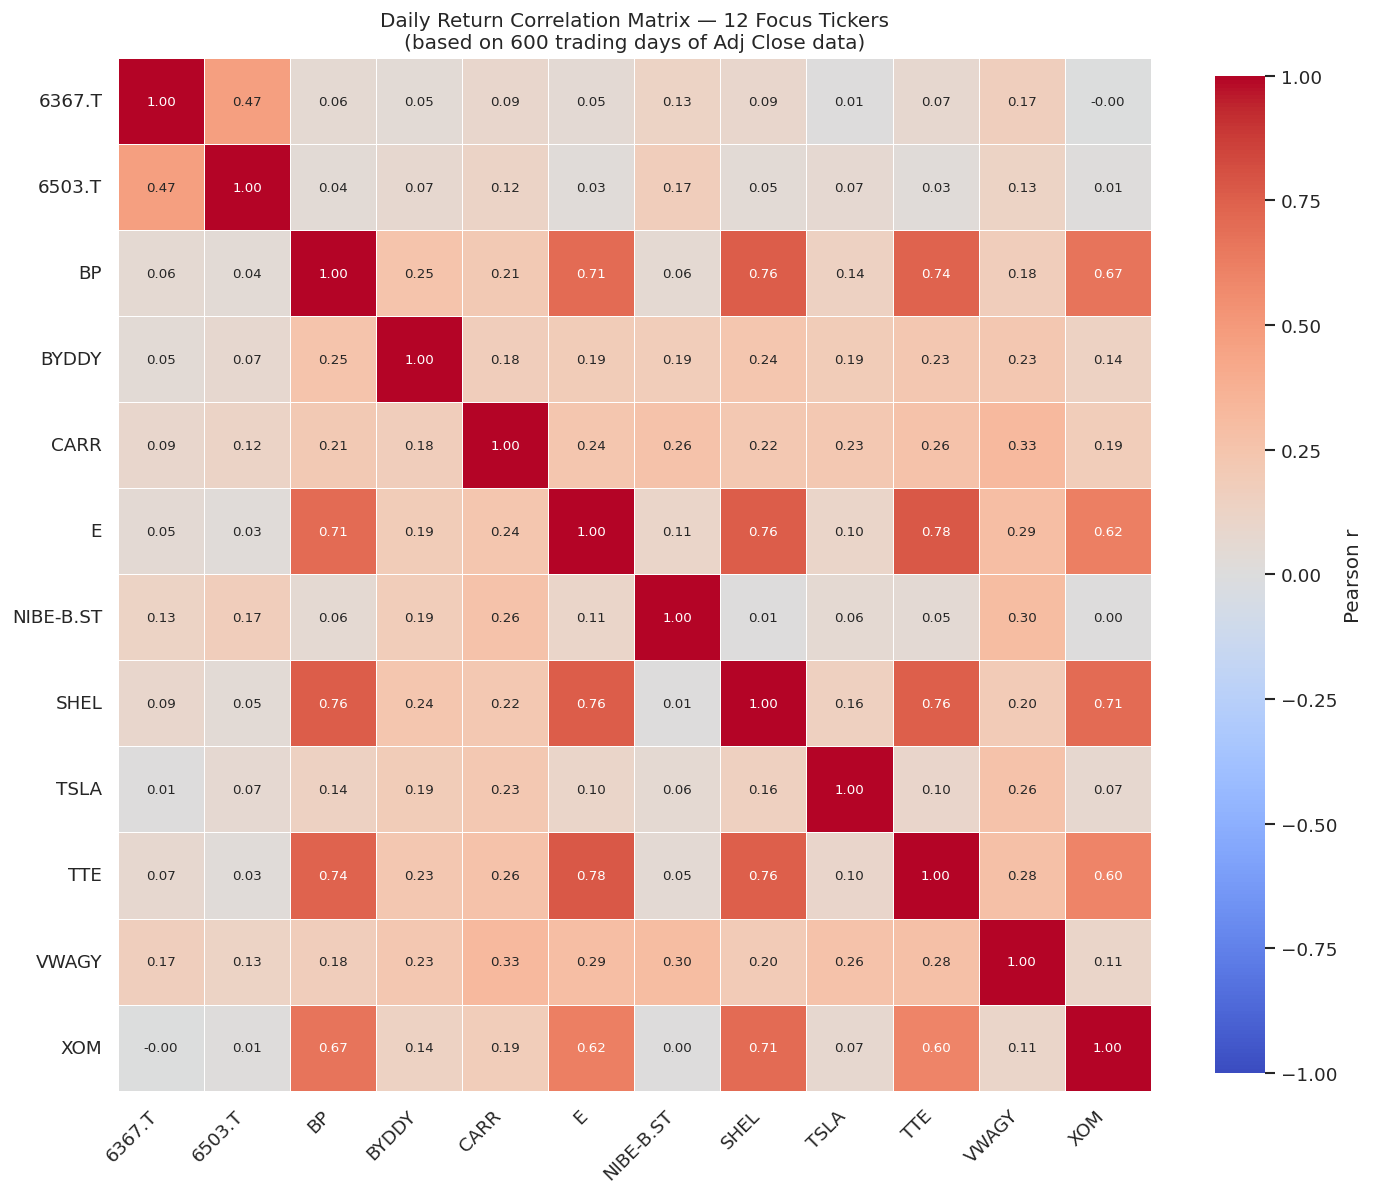

Most correlated pair: E ↔ TTE  r = 0.776


In [227]:
# ---------------------------------------------------------------------------
# Pairwise Pearson correlation of daily Adj Close returns across Focus Tickers.
# Only tickers present in the price CSV are included.
# ---------------------------------------------------------------------------

import seaborn as sns

# Use only focus tickers that have price data
avail_tickers = [t for t in FOCUS_TICKERS if t in prices["Ticker"].unique()]

# Build wide returns table: rows = trading dates, columns = tickers
returns_wide = (
    prices_sorted[prices_sorted["Ticker"].isin(avail_tickers)]
    .pivot_table(index="Date", columns="Ticker", values="Adj Close")
    .pct_change()
    .dropna(how="all")
)

corr = returns_wide.corr()

# Pretty ticker labels (shorten long names for readability)
fig, ax = plt.subplots(figsize=(max(8, len(avail_tickers)), max(6, len(avail_tickers) - 1)))
mask = pd.DataFrame(False, index=corr.index, columns=corr.columns)

sns.heatmap(
    corr,
    ax=ax,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    square=True,
    annot_kws={"size": 8},
    cbar_kws={"shrink": 0.8, "label": "Pearson r"},
)
ax.set_title(
    f"Daily Return Correlation Matrix — {len(avail_tickers)} Focus Tickers\n"
    f"(based on {len(returns_wide):,} trading days of Adj Close data)",
    fontsize=12,
)
ax.set_xlabel("")
ax.set_ylabel("")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Print the most correlated pair (excluding self)
corr_vals = corr.unstack()
corr_vals = corr_vals[corr_vals.index.get_level_values(0) != corr_vals.index.get_level_values(1)]
top_pair = corr_vals.abs().idxmax()
print(f"Most correlated pair: {top_pair[0]} ↔ {top_pair[1]}  r = {corr_vals[top_pair]:.3f}")

## 4.5 — Cross-Source Alignment: Tweets ↔ Prices

In [228]:
# Compare tweet and price date ranges to find the overlapping period.
# Only tweets within the overlap can be matched to daily price data.
# Handles timezone-aware tweet timestamps vs. timezone-naive price dates.
tweet_min = tweets["posted_at"].min()
tweet_max = tweets["posted_at"].max()
price_min = prices["Date"].min()
price_max = prices["Date"].max()

# Strip timezone info for comparison (tweets are UTC, prices are tz-naive)
tweet_min_naive = tweet_min.tz_localize(None) if tweet_min.tzinfo else tweet_min
tweet_max_naive = tweet_max.tz_localize(None) if tweet_max.tzinfo else tweet_max

overlap_start = max(tweet_min_naive, price_min)
overlap_end = min(tweet_max_naive, price_max)

print(f"Tweet range:   {tweet_min_naive:%Y-%m-%d} → {tweet_max_naive:%Y-%m-%d}")
print(f"Price range:   {price_min:%Y-%m-%d} → {price_max:%Y-%m-%d}")
print(f"Overlap:       {overlap_start:%Y-%m-%d} → {overlap_end:%Y-%m-%d}")
print(f"Overlap days:  {(overlap_end - overlap_start).days}")

# Count how many tweets fall within the overlap period
tweets_posted_naive = tweets["posted_at"].dt.tz_localize(None) if tweets["posted_at"].dt.tz else tweets["posted_at"]
tweets_in_overlap = tweets[
    (tweets_posted_naive >= overlap_start) & (tweets_posted_naive <= overlap_end)
]
print(f"Tweets within overlap: {len(tweets_in_overlap)} of {len(tweets)} ({len(tweets_in_overlap)/len(tweets):.1%})")

Tweet range:   2026-01-01 → 2026-05-18
Price range:   2024-01-02 → 2026-04-23
Overlap:       2026-01-01 → 2026-04-23
Overlap days:  111
Tweets within overlap: 3092 of 5151 (60.0%)


### 4.5b — Tweets on Non-Trading Days

In [229]:
# Identify tweets posted on non-trading days (weekends, NYSE holidays).
# These tweets can't be directly matched to same-day price movements.
# Strategy needed: map to next trading day, or analyze separately.
tweet_dates_norm = tweets["posted_at"].dt.tz_localize(None).dt.normalize() if tweets["posted_at"].dt.tz else tweets["posted_at"].dt.normalize()
trading_days_set = set(trading_days)

# Flag each tweet as trading day or non-trading day
tweets["is_trading_day"] = tweet_dates_norm.isin(trading_days_set)
tweets["day_of_week"] = tweets["posted_at"].dt.day_name()

n_trading = tweets["is_trading_day"].sum()
n_non_trading = (~tweets["is_trading_day"]).sum()

print(f"Tweets on trading days:      {n_trading} ({n_trading/len(tweets):.1%})")
print(f"Tweets on non-trading days:  {n_non_trading} ({n_non_trading/len(tweets):.1%})")
print()
# Break down non-trading tweets by weekday to distinguish weekends from holidays
print("Non-trading day breakdown by weekday:")
non_td = tweets[~tweets["is_trading_day"]]
print(non_td["day_of_week"].value_counts().to_string())

Tweets on trading days:      2431 (47.2%)
Tweets on non-trading days:  2720 (52.8%)

Non-trading day breakdown by weekday:
day_of_week
Sunday       589
Saturday     458
Wednesday    362
Monday       360
Friday       334
Tuesday      318
Thursday     299


### 4.5c — Exploratory Lag Analysis: Tweet Volume → Next-Day Return

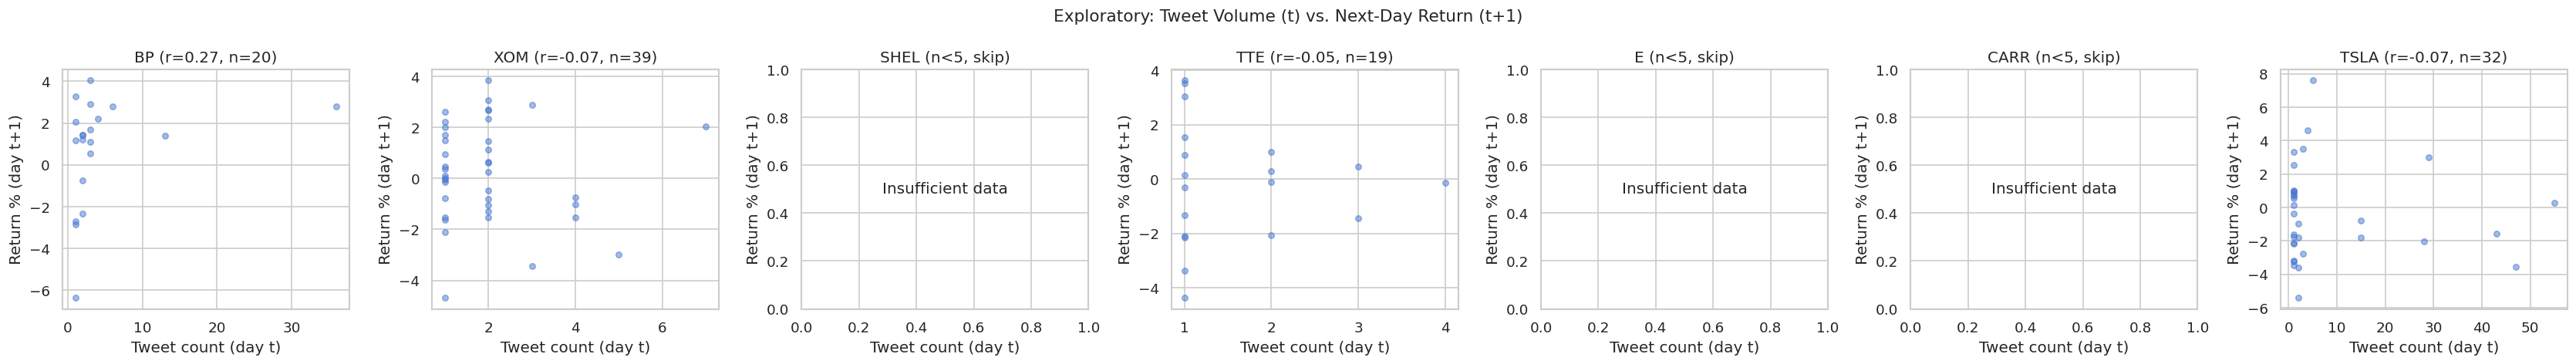

In [230]:
# Exploratory lag analysis: does tweet volume on day t correlate with
# the stock return on day t+1? This is a first look at predictive signal.
# Scatter plots with Pearson correlation for each focus ticker.
# Only tickers with matching tweet data are included.
target_tickers = [t for t in FOCUS_TICKERS if t in tweets["symbol"].values]

if not target_tickers:
    print("No focus tickers found in tweet data — skipping lag analysis.")
else:
    fig, axes = plt.subplots(1, len(target_tickers), figsize=(4 * len(target_tickers), 4))
    if len(target_tickers) == 1:
        axes = [axes]

    for ax, ticker in zip(axes, target_tickers):
        # Count tweets per day for this ticker
        tw = tweets[tweets["symbol"] == ticker].copy()
        tw_daily = tw.groupby(tw["posted_at"].dt.tz_localize(None).dt.normalize() if tw["posted_at"].dt.tz else tw["posted_at"].dt.normalize()).size().rename("tweet_count")

        # Get daily returns for this ticker
        ret = prices_sorted[prices_sorted["Ticker"] == ticker][["Date", "return_pct"]].copy()
        ret["Date"] = ret["Date"].dt.normalize()
        ret = ret.set_index("Date")["return_pct"]

        # Align: tweet volume on day t → return on day t+1 (shift returns back by 1)
        combined = pd.DataFrame({"tweet_count": tw_daily, "return_t1": ret.shift(-1)}).dropna()

        if len(combined) >= 5:
            ax.scatter(combined["tweet_count"], combined["return_t1"], alpha=0.5, s=20)
            corr = combined["tweet_count"].corr(combined["return_t1"])
            ax.set_title(f"{ticker} (r={corr:.2f}, n={len(combined)})")
        else:
            ax.set_title(f"{ticker} (n<5, skip)")
            ax.text(0.5, 0.5, "Insufficient data", ha="center", va="center", transform=ax.transAxes)

        ax.set_xlabel("Tweet count (day t)")
        ax.set_ylabel("Return % (day t+1)")

    fig.suptitle("Exploratory: Tweet Volume (t) vs. Next-Day Return (t+1)", fontsize=13)
    plt.tight_layout()
    plt.show()


## 5 — Coverage Matrix: Tweets with Price Data by Ticker × Week

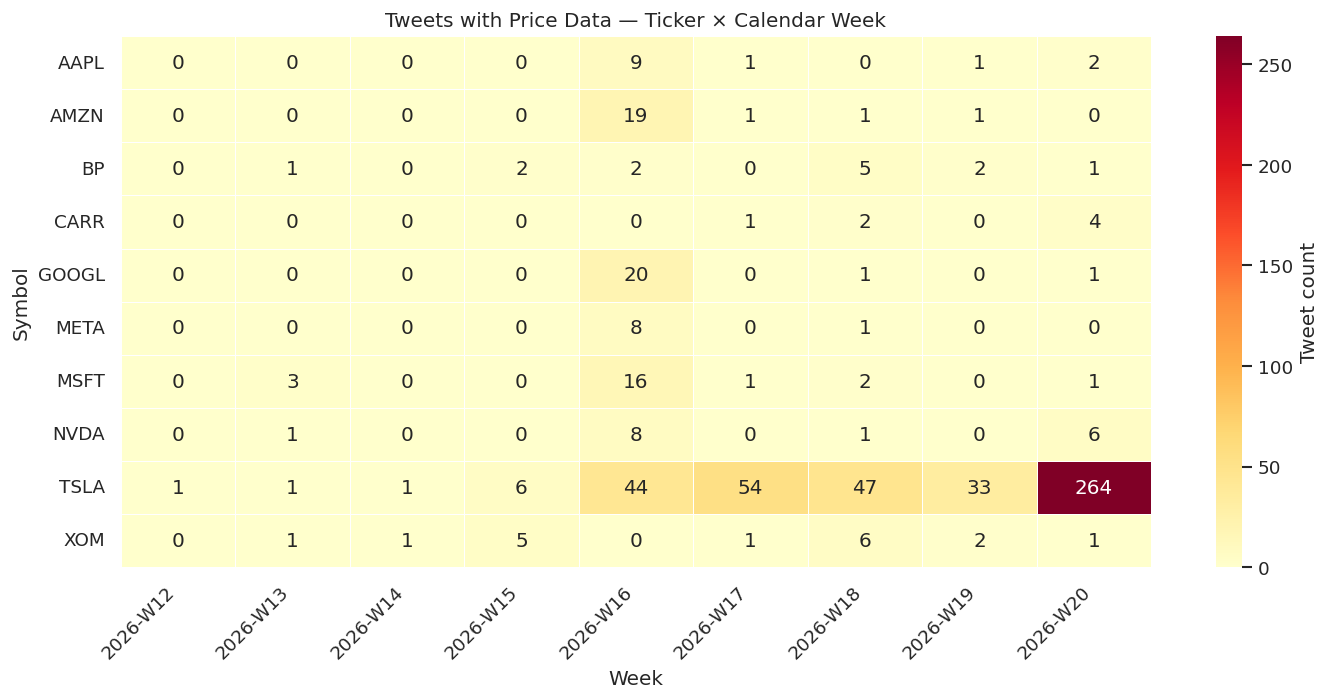

In [231]:
# Heatmap: tweets with price data, broken down by ticker × calendar week.
# Reveals temporal coverage patterns — which tickers have data in which weeks?
# Empty cells = no tweets with price snapshots for that ticker/week combination.
df_cov = tweets_with_price_flag[
    tweets_with_price_flag["symbol"].notna() & tweets_with_price_flag["has_price"]
].copy()
df_cov["week"] = df_cov["posted_at"].dt.isocalendar().week.astype(int)
df_cov["year_week"] = (
    df_cov["posted_at"].dt.isocalendar().year.astype(str)
    + "-W"
    + df_cov["week"].astype(str).str.zfill(2)
)

# Focus on top 10 symbols by tweet count
top_symbols = df_cov["symbol"].value_counts().head(10).index.tolist()
df_cov_top = df_cov[df_cov["symbol"].isin(top_symbols)]

# Pivot table: rows = symbols, columns = calendar weeks, values = tweet count
pivot = df_cov_top.pivot_table(
    index="symbol", columns="year_week", values="tweet_id", aggfunc="count", fill_value=0
)

fig, ax = plt.subplots(figsize=(max(12, len(pivot.columns) * 0.6), 6))
sns.heatmap(
    pivot,
    annot=True, fmt="d", cmap="YlOrRd", linewidths=0.5, ax=ax,
    cbar_kws={"label": "Tweet count"}
)
ax.set_title("Tweets with Price Data — Ticker × Calendar Week")
ax.set_ylabel("Symbol")
ax.set_xlabel("Week")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 6 — Historical Price Time Series

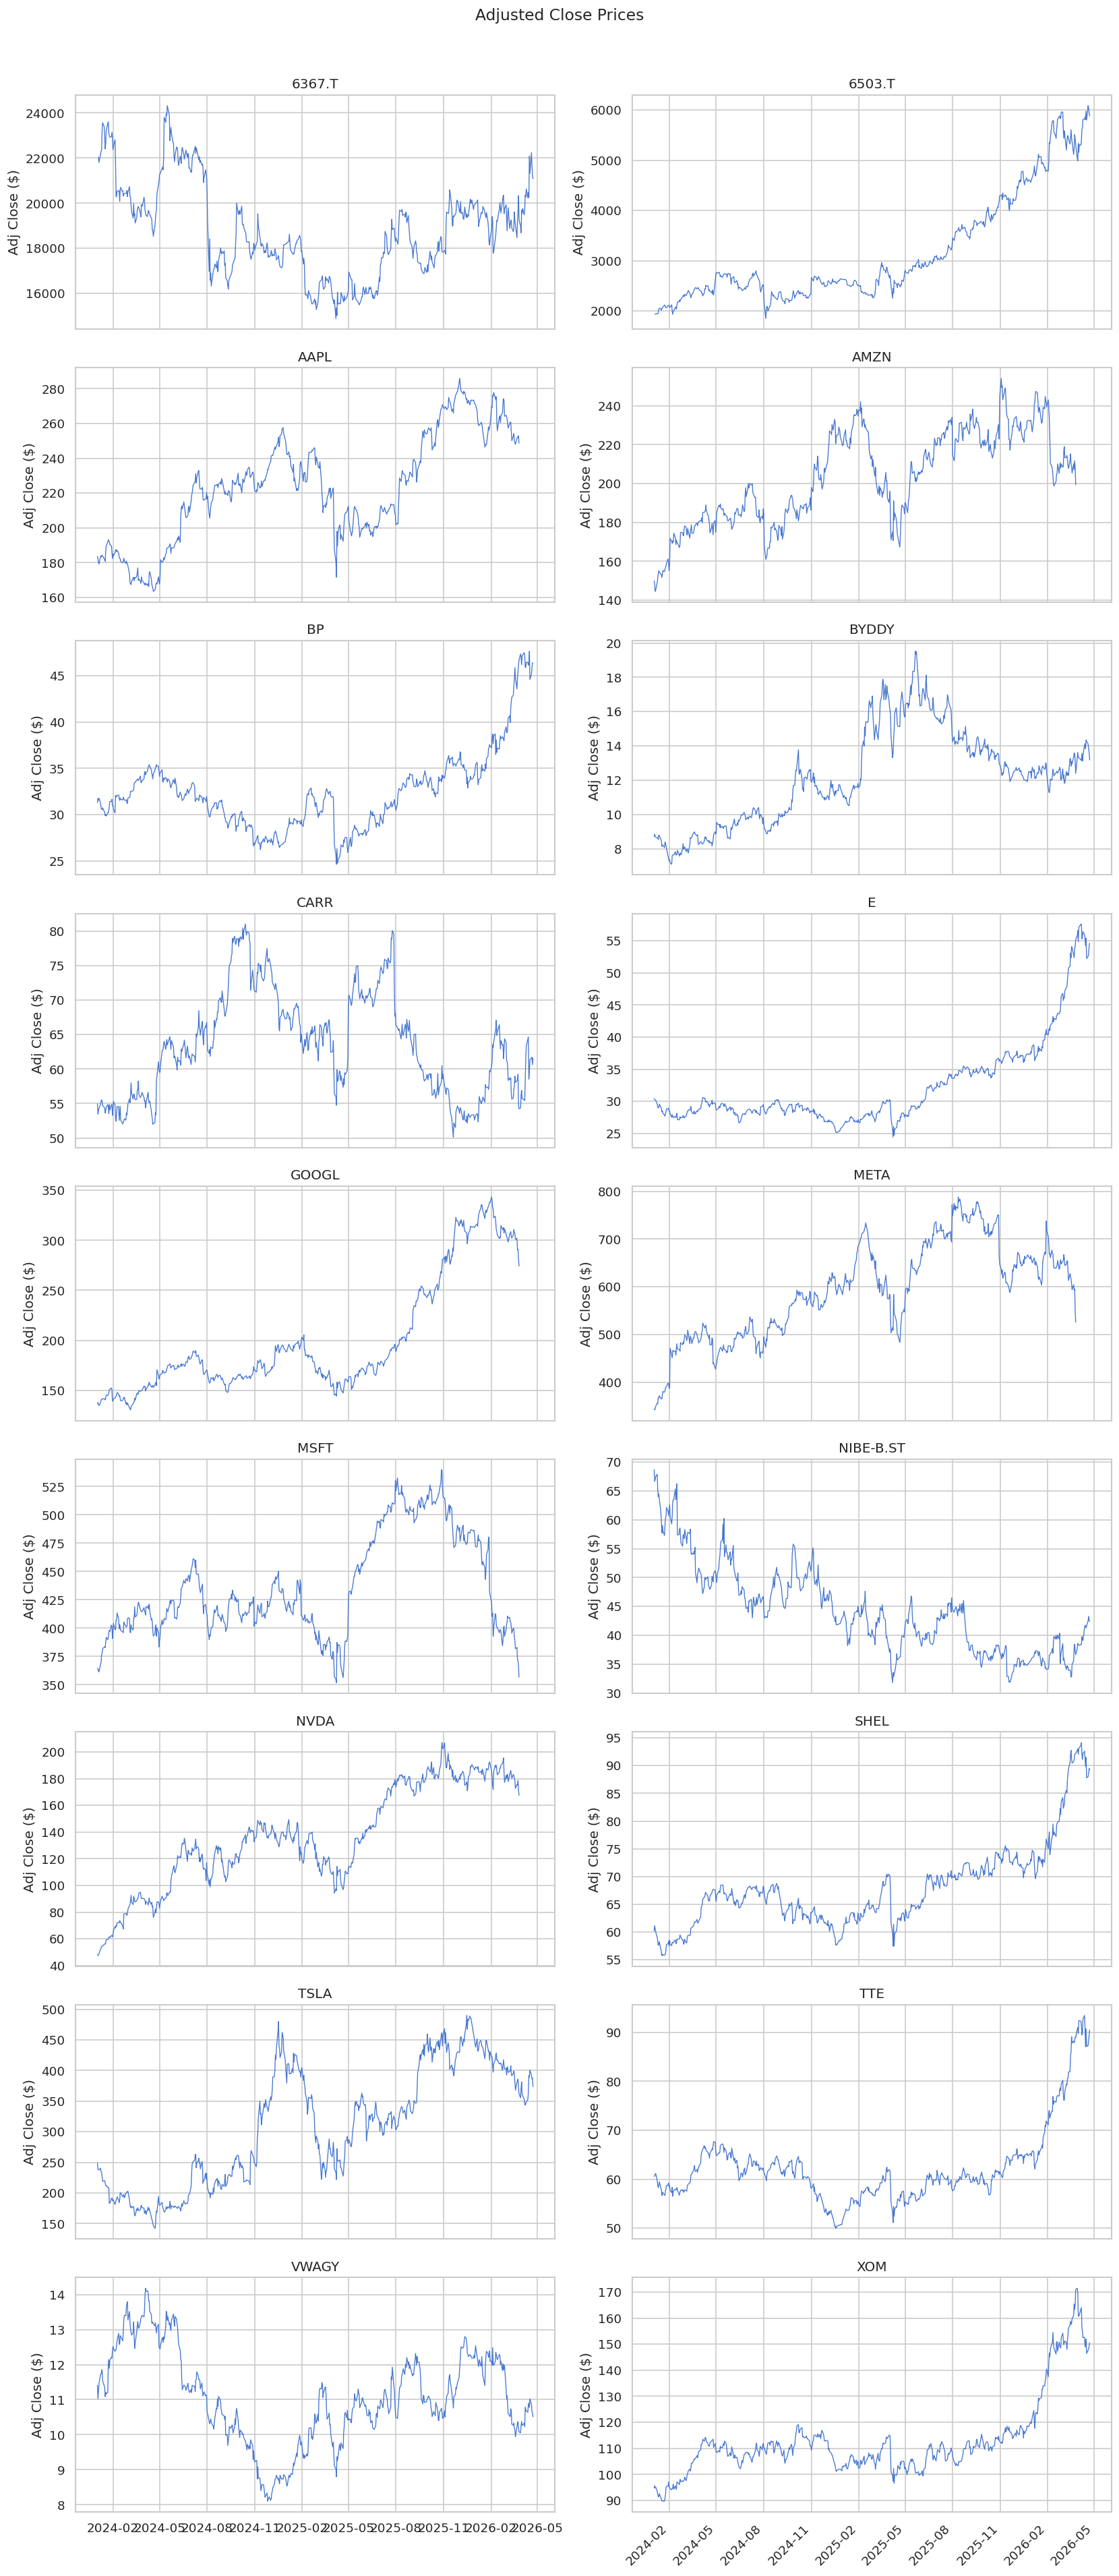

In [232]:
# Individual Adjusted Close price charts per ticker (subplots).
# Visual check for data gaps, suspicious flat periods, or price anomalies.
tickers = sorted(prices["Ticker"].unique())
n_tickers = len(tickers)
ncols = 2
nrows = (n_tickers + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.5 * nrows), sharex=True)
axes = axes.flatten()

for i, ticker in enumerate(tickers):
    ax = axes[i]
    subset = prices[prices["Ticker"] == ticker]
    ax.plot(subset["Date"], subset["Adj Close"], linewidth=0.8)
    ax.set_title(ticker)
    ax.set_ylabel("Adj Close ($)")
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

# Hide unused subplot axes (when ticker count is odd)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Adjusted Close Prices", fontsize=14, y=1.01)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

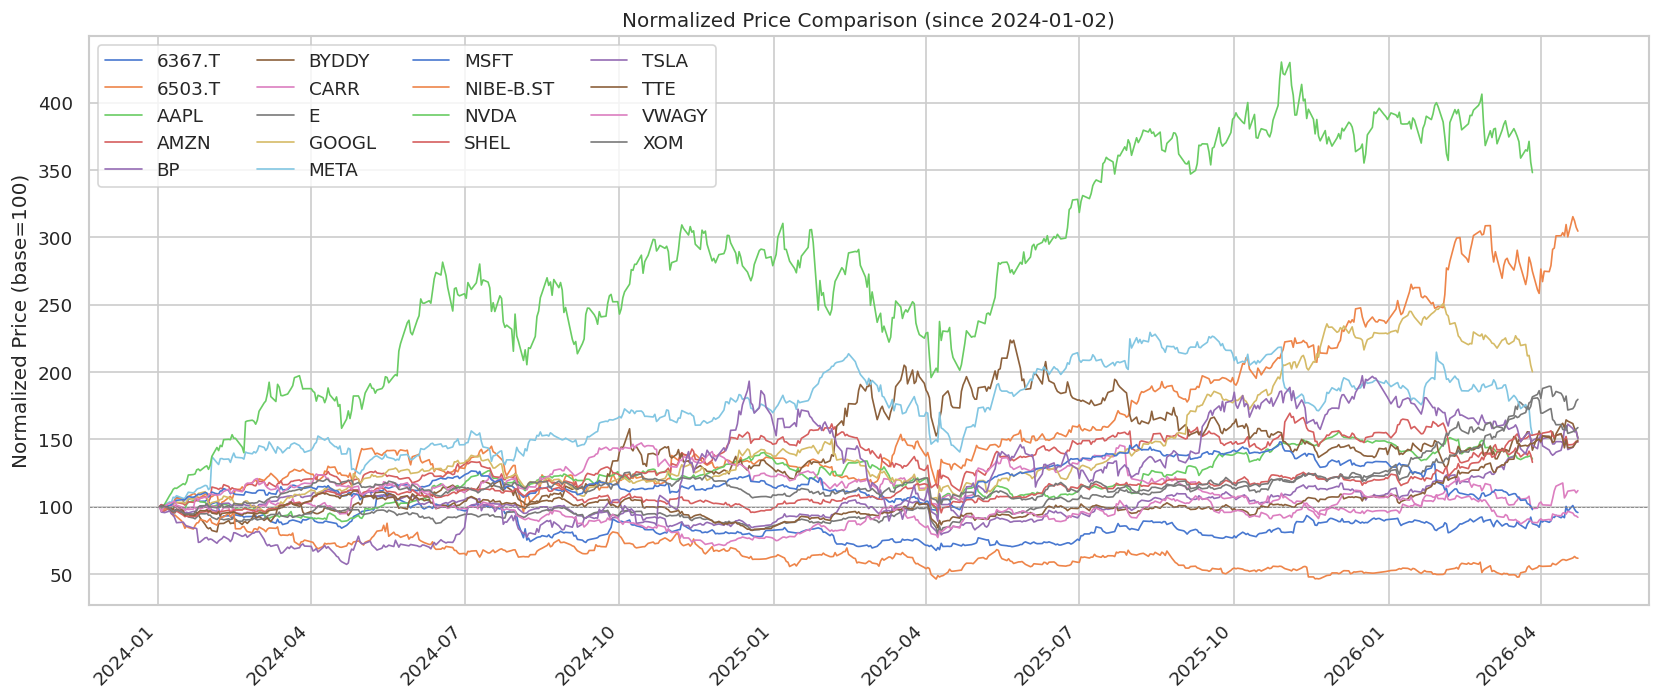

In [233]:
# Normalized price comparison: all tickers on the same scale (base = 100).
# Makes it easy to compare relative performance regardless of absolute price level.
fig, ax = plt.subplots(figsize=(14, 6))

for ticker in tickers:
    subset = prices[prices["Ticker"] == ticker].sort_values("Date")
    base = subset["Adj Close"].iloc[0]  # First day's price = 100
    ax.plot(subset["Date"], subset["Adj Close"] / base * 100, label=ticker, linewidth=1)

ax.axhline(100, color="grey", linewidth=0.5, linestyle="--")
ax.set_ylabel("Normalized Price (base=100)")
ax.set_title("Normalized Price Comparison (since 2024-01-02)")
ax.legend(loc="upper left", ncol=4)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 7 — Tweet Volume & Timing

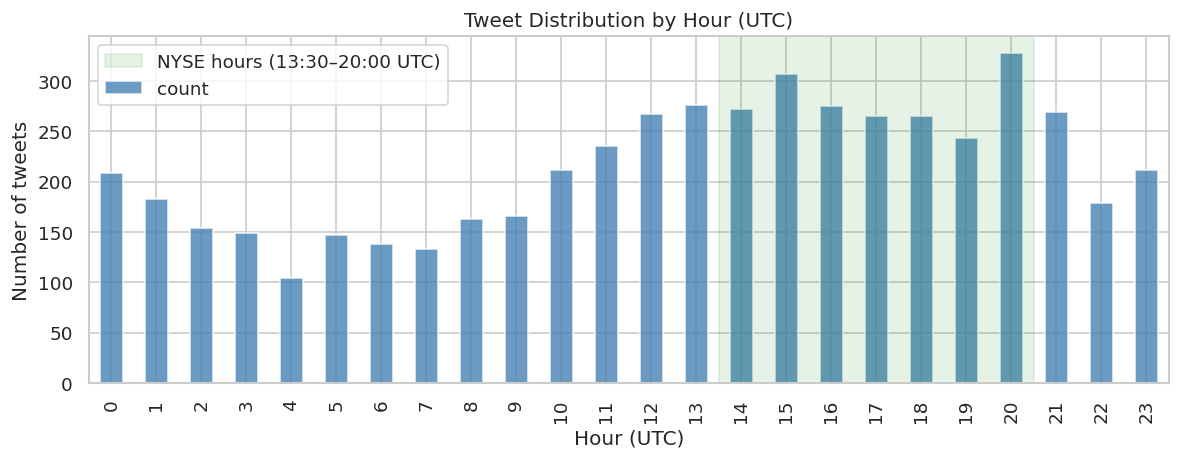

In [234]:
# Hourly distribution of tweets (UTC). Highlights when most tweets are posted.
# Green band marks NYSE regular trading hours (13:30–20:00 UTC / 9:30–16:00 ET).
tweets["hour"] = tweets["posted_at"].dt.hour

fig, ax = plt.subplots(figsize=(10, 4))
tweets["hour"].value_counts().sort_index().plot.bar(ax=ax, color="steelblue", alpha=0.8)
ax.set_xlabel("Hour (UTC)")
ax.set_ylabel("Number of tweets")
ax.set_title("Tweet Distribution by Hour (UTC)")
ax.axvspan(13.5, 20.5, alpha=0.1, color="green", label="NYSE hours (13:30–20:00 UTC)")
ax.legend()
plt.tight_layout()
plt.show()

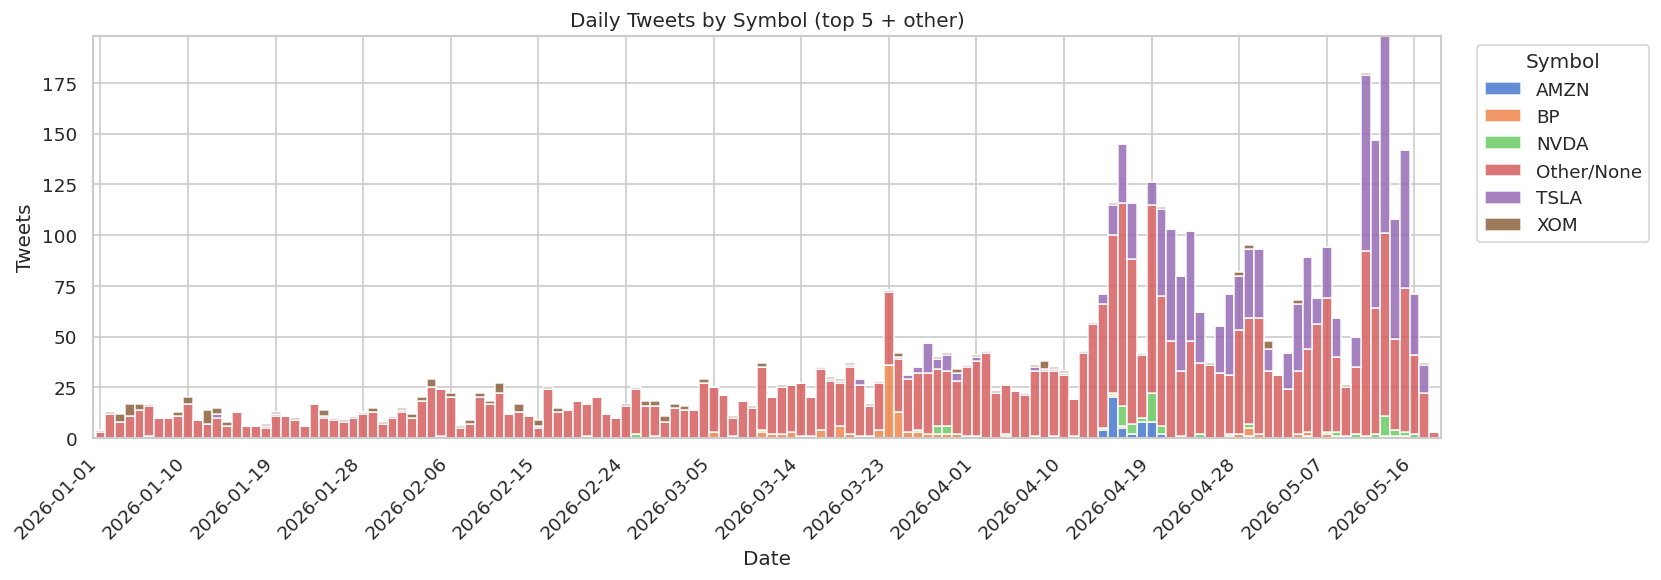

In [235]:

# Stacked bar chart: daily tweet volume broken down by the top 5 symbols.
# "Other/None" groups all remaining symbols and tweets without a cashtag.
top5 = tweets["symbol"].value_counts().head(5).index.tolist()
tweets["symbol_group"] = tweets["symbol"].where(tweets["symbol"].isin(top5), other="Other/None")
# Use date string (YYYY-MM-DD) as index — avoids tz-aware datetime issues with bar chart
tweets["date_dt"] = tweets["posted_at"].dt.strftime("%Y-%m-%d")

daily_symbol = (
    tweets.groupby(["date_dt", "symbol_group"]).size().unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(14, 5))
daily_symbol.plot.bar(stacked=True, ax=ax, width=1, alpha=0.85)
ax.set_xlabel("Date")
ax.set_ylabel("Tweets")
ax.set_title("Daily Tweets by Symbol (top 5 + other)")
# Reduce x-tick clutter: show only every Nth label
n_ticks = len(daily_symbol)
step = max(1, n_ticks // 15)
ax.set_xticks(range(0, n_ticks, step))
ax.set_xticklabels(
    [daily_symbol.index[i] for i in range(0, n_ticks, step)], rotation=45, ha="right"
)
ax.legend(title="Symbol", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## 8 — Tweet–Price Overlay (Top Tickers)

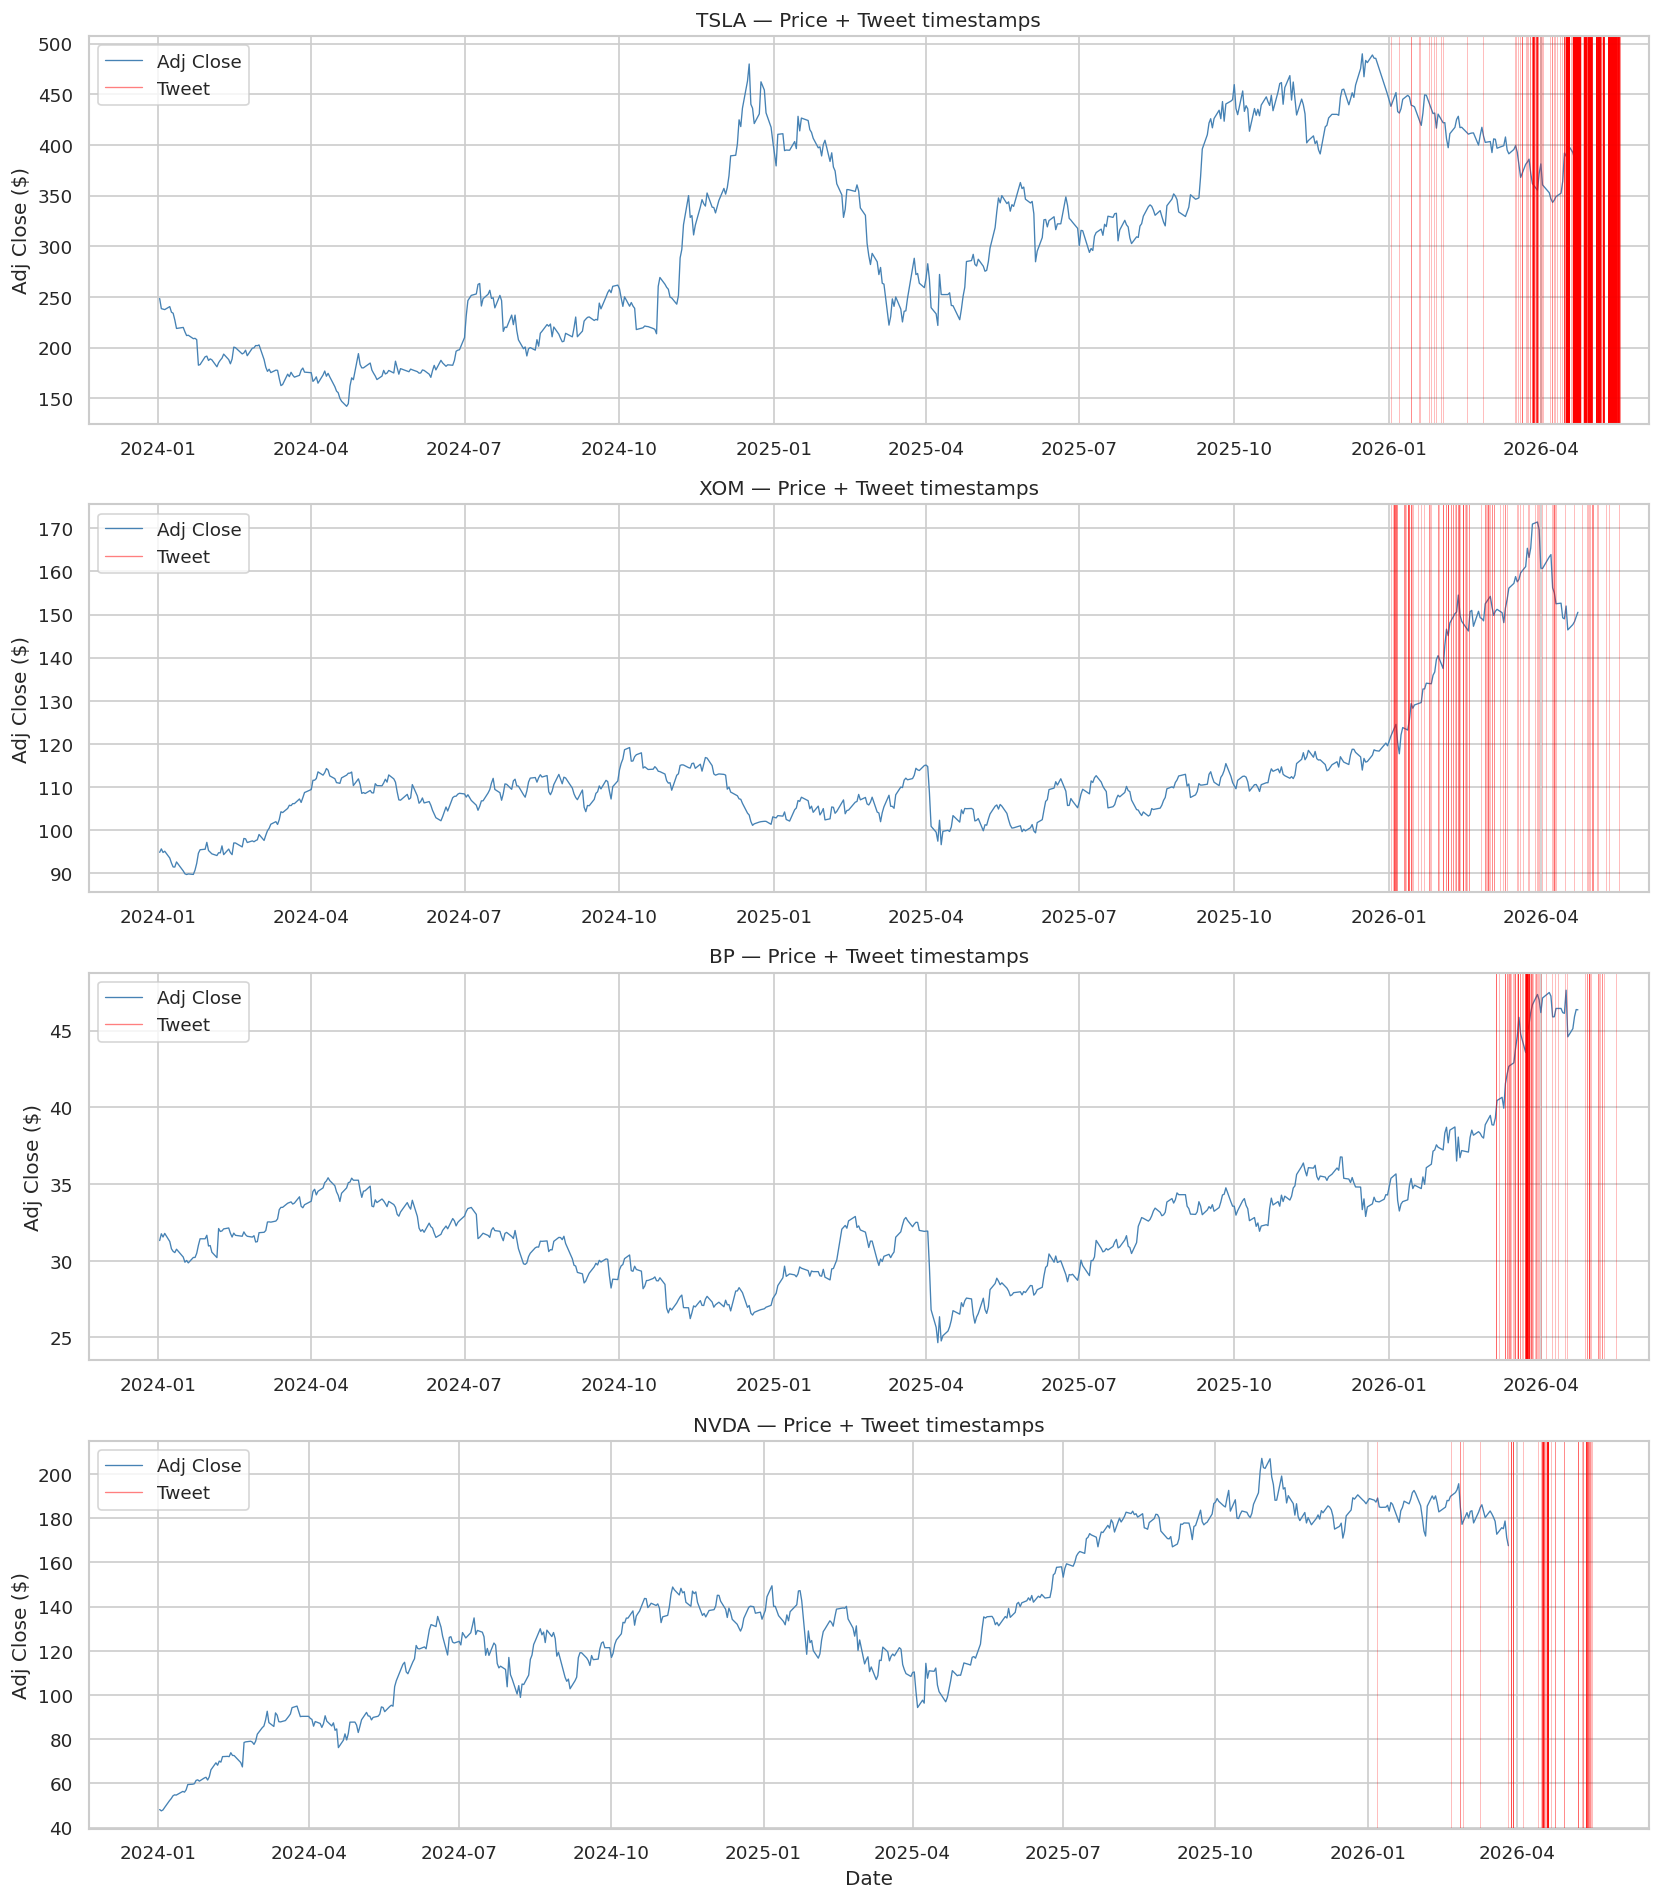

In [236]:
# Overlay plot: daily Adj Close price line + red vertical lines for each tweet.
# Shows when tweets cluster relative to price movements.
# Limited to top 4 tickers that appear in both tweet and price datasets.
from matplotlib.lines import Line2D

csv_tickers = set(prices["Ticker"].unique())
overlay_tickers = [t for t in top5 if t in csv_tickers][:4]

fig, axes = plt.subplots(len(overlay_tickers), 1, figsize=(14, 4 * len(overlay_tickers)), sharex=False)
if len(overlay_tickers) == 1:
    axes = [axes]

for ax, ticker in zip(axes, overlay_tickers):
    # Plot the daily price line
    p = prices[prices["Ticker"] == ticker].sort_values("Date")
    ax.plot(p["Date"], p["Adj Close"], color="steelblue", linewidth=0.8, label="Adj Close")

    # Add a vertical line for each tweet timestamp
    tw = tweets[tweets["symbol"] == ticker]
    for _, row in tw.iterrows():
        ax.axvline(row["posted_at"], color="red", alpha=0.3, linewidth=0.5)

    ax.set_title(f"{ticker} — Price + Tweet timestamps")
    ax.set_ylabel("Adj Close ($)")
    # Custom legend entry for tweets (Line2D avoids pd.NaT crash)
    handles, labels = ax.get_legend_handles_labels()
    handles.append(Line2D([0], [0], color="red", alpha=0.5, linewidth=0.8))
    labels.append("Tweet")
    ax.legend(handles=handles, labels=labels, loc="upper left")

plt.xlabel("Date")
plt.tight_layout()
plt.show()

## 9 — Follower & Engagement Analysis

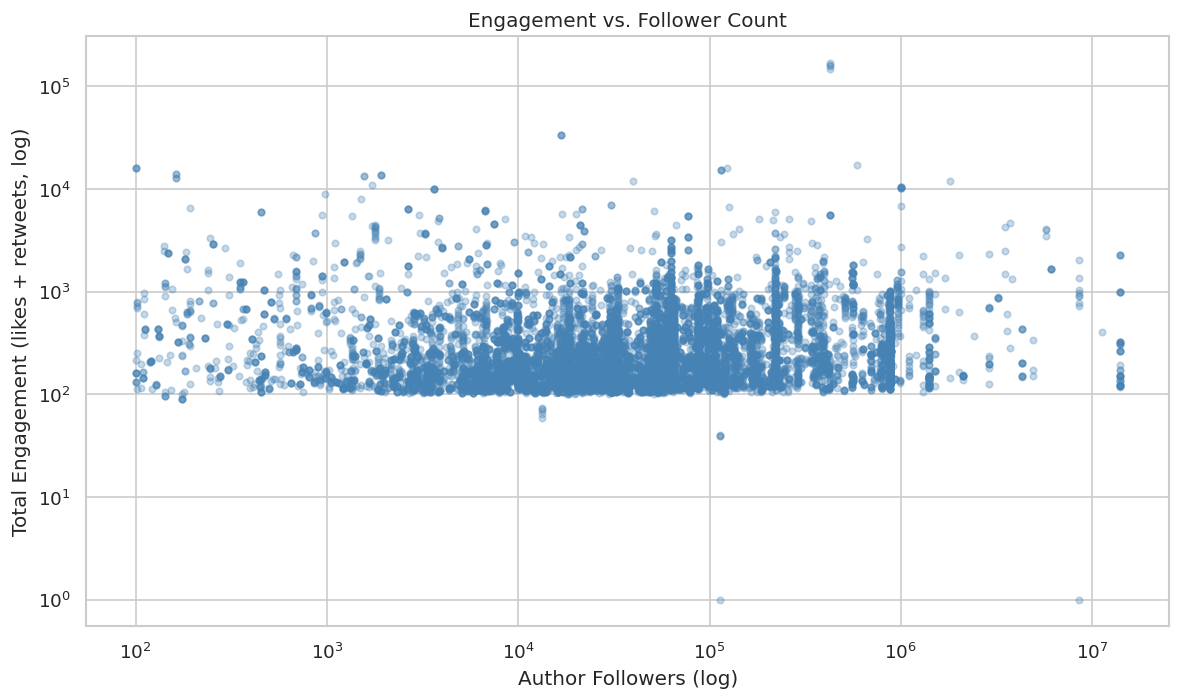

In [237]:
# Scatter plot: author follower count vs. total engagement (log-log scale).
# Tests whether high-follower authors actually generate more engagement.
# Log scale because both distributions are heavily right-skewed.
merged["total_engagement"] = merged["likes"].fillna(0) + merged["retweets"].fillna(0)

fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(
    merged["author_followers"].clip(lower=1),
    merged["total_engagement"].clip(lower=1),
    alpha=0.3, s=15, c="steelblue"
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Author Followers (log)")
ax.set_ylabel("Total Engagement (likes + retweets, log)")
ax.set_title("Engagement vs. Follower Count")
plt.tight_layout()
plt.show()

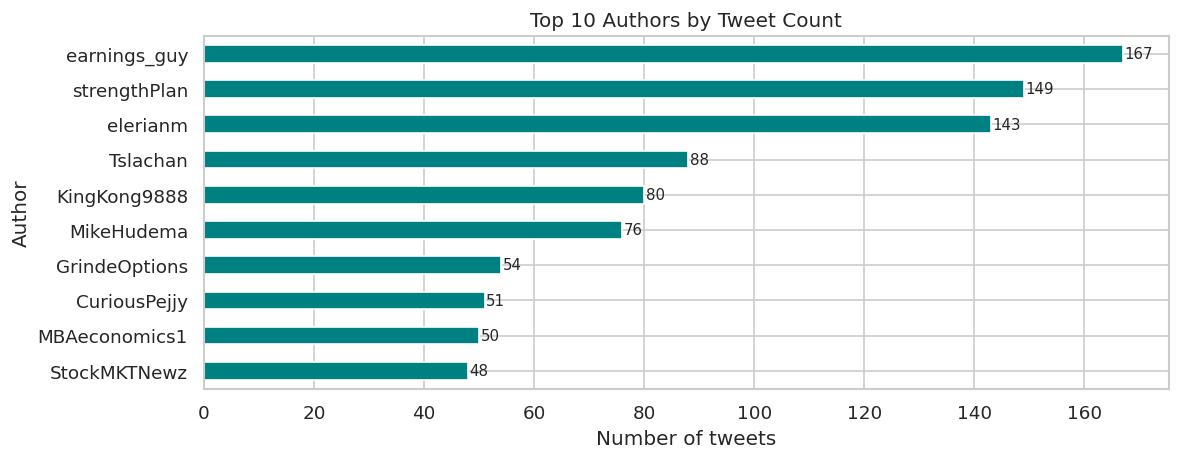

In [238]:
# Top 10 most prolific authors by tweet count.
# High-volume authors may be bots or financial influencers — worth investigating.
top_authors = tweets["author"].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 4))
top_authors.plot.barh(ax=ax, color="teal")
ax.set_xlabel("Number of tweets")
ax.set_ylabel("Author")
ax.set_title("Top 10 Authors by Tweet Count")
ax.invert_yaxis()
for i, v in enumerate(top_authors.values):
    ax.text(v + 0.3, i, str(v), va="center", fontsize=9)
plt.tight_layout()
plt.show()

## 10 — Summary & Recommendations

In [239]:

# Auto-generate a summary table with all key metrics from previous sections.
from IPython.display import Markdown, display

date_min = tweets["posted_at"].min()
date_max = tweets["posted_at"].max()

# Detect days with zero tweets (collection gaps)
all_days = pd.date_range(date_min.normalize(), date_max.normalize(), freq="D")
active_days = set(tweets["posted_at"].dt.normalize())
gap_days = sorted(set(all_days) - active_days)

# Find the longest consecutive gap (streak of days with no tweets)
if gap_days:
    gap_series = pd.Series(gap_days)
    gap_groups = (gap_series.diff().dt.days != 1).cumsum()
    longest_gap = (
        gap_series.groupby(gap_groups)
        .agg(["first", "last", "count"])
        .sort_values("count", ascending=False)
        .iloc[0]
    )
    gap_str = (
        f"{longest_gap['first']:%Y-%m-%d} → {longest_gap['last']:%Y-%m-%d} "
        f"({int(longest_gap['count'])} days)"
    )
else:
    gap_str = "None"

# Metrics from earlier sections (safe fallback for partial execution)
n_dup_content = tweets["content"].duplicated().sum()
n_empty = tweets["content"].isna().sum() + (tweets["content"].str.strip() == "").sum()
en_share = (tweets["lang"] == "en").mean() if "lang" in tweets.columns else float("nan")
n_outlier_returns = int(prices_sorted["is_outlier"].sum()) if "is_outlier" in prices_sorted.columns else 0
n_td = int(tweets["is_trading_day"].sum()) if "is_trading_day" in tweets.columns else 0
n_ntd = int((~tweets["is_trading_day"]).sum()) if "is_trading_day" in tweets.columns else 0
n_viral_sum = int((merged["total_engagement"] >= merged["total_engagement"].quantile(0.95)).sum()) if "total_engagement" in merged.columns else 0

# Metrics from new sections (2.5 / 2.6 / 2.7)
try:
    _n_sufficient = int(n_sufficient)
    _min_req = int(MIN_TWEETS_REQUIRED)
except NameError:
    _n_sufficient, _min_req = 0, 30
try:
    _rt_share = float(rt_share)
    _n_rt = int(n_rt)
except NameError:
    _rt_share, _n_rt = float("nan"), 0
try:
    _n_bot_candidates = int(n_bot_candidates)
    _n_bot_accounts = int(n_bot_accounts)
    _bot_tweet_share = float(bot_tweet_share)
except NameError:
    _n_bot_candidates, _n_bot_accounts, _bot_tweet_share = 0, 0, float("nan")

summary = f"""
### Key Findings

| Metric | Value |
|--------|-------|
| Total tweets collected | {len(tweets):,} |
| Tweets with cashtag | {n_with_symbol:,} ({n_with_symbol/n_total:.1%}) |
| Unique symbols | {tweets['symbol'].nunique()} |
| Tweets with price snapshots | {n_with_prices:,} ({n_with_prices/len(tweets):.1%}) |
| Duplicate content tweets | {n_dup_content} |
| Empty / NaN content | {n_empty} |
| English tweet share | {en_share:.1%} |
| **Retweet share (RT @)** | **{_n_rt:,} ({_rt_share:.1%})** |
| **Potential bot-candidate tweets** | **{_n_bot_candidates:,} ({_bot_tweet_share:.1%}) from {_n_bot_accounts} accounts** |
| Viral tweets (≥P95 engagement) | {n_viral_sum} |
| Tweets on trading days | {n_td} ({n_td/len(tweets):.1%}) |
| Tweets on non-trading days | {n_ntd} ({n_ntd/len(tweets):.1%}) |
| Tweet date range | {date_min:%Y-%m-%d} → {date_max:%Y-%m-%d} |
| Days with zero tweets | {len(gap_days)} |
| Longest gap | {gap_str} |
| **Focus Tickers with ≥{_min_req} tweets** | **{_n_sufficient} / {len(FOCUS_TICKERS)}** |
| Historical price tickers | {len(prices['Ticker'].unique())} |
| Price rows (CSV) | {len(prices):,} |
| Outlier returns (IQR×3) | {n_outlier_returns} |

### Recommendations

1. **Address tweet gap**: The longest gap ({gap_str}) likely corresponds to X session-expiry.
   Mark this period as missing in downstream analysis.
2. **Filter retweets before sentiment**: RT share = {_rt_share:.1%}.
   Retweets duplicate signals — exclude or weight-adjust them in the sentiment pipeline.
3. **Review bot candidates**: {_n_bot_candidates:,} tweets ({_bot_tweet_share:.1%}) come from
   {_n_bot_accounts} zero-follower high-frequency accounts. Consider excluding before modeling.
4. **Focus on sufficient tickers**: Only {_n_sufficient}/{len(FOCUS_TICKERS)} Focus Tickers have
   ≥{_min_req} tweets. Restrict sentiment correlation to those tickers.
5. **Handle after-hours tweets**: Many tweets lack price snapshots (posted outside market hours).
   Decide whether to map to next-open or exclude.
6. **Next step → Notebook 02**: Run sentiment models on filtered tweet content and align with prices.
"""

display(Markdown(summary))



### Key Findings

| Metric | Value |
|--------|-------|
| Total tweets collected | 5,151 |
| Tweets with cashtag | 2,359 (45.8%) |
| Unique symbols | 237 |
| Tweets with price snapshots | 723 (14.0%) |
| Duplicate content tweets | 87 |
| Empty / NaN content | 0 |
| English tweet share | 95.3% |
| **Retweet share (RT @)** | **0 (0.0%)** |
| **Potential bot-candidate tweets** | **0 (0.0%) from 0 accounts** |
| Viral tweets (≥P95 engagement) | 621 |
| Tweets on trading days | 2431 (47.2%) |
| Tweets on non-trading days | 2720 (52.8%) |
| Tweet date range | 2026-01-01 → 2026-05-18 |
| Days with zero tweets | 0 |
| Longest gap | None |
| **Focus Tickers with ≥30 tweets** | **7 / 12** |
| Historical price tickers | 18 |
| Price rows (CSV) | 10,280 |
| Outlier returns (IQR×3) | 82 |

### Recommendations

1. **Address tweet gap**: The longest gap (None) likely corresponds to X session-expiry.
   Mark this period as missing in downstream analysis.
2. **Filter retweets before sentiment**: RT share = 0.0%.
   Retweets duplicate signals — exclude or weight-adjust them in the sentiment pipeline.
3. **Review bot candidates**: 0 tweets (0.0%) come from
   0 zero-follower high-frequency accounts. Consider excluding before modeling.
4. **Focus on sufficient tickers**: Only 7/12 Focus Tickers have
   ≥30 tweets. Restrict sentiment correlation to those tickers.
5. **Handle after-hours tweets**: Many tweets lack price snapshots (posted outside market hours).
   Decide whether to map to next-open or exclude.
6. **Next step → Notebook 02**: Run sentiment models on filtered tweet content and align with prices.


## 11 — Virality Score & Engagement Velocity

Tweets are tracked every 15 minutes for 2 hours after discovery (`tweet_snapshots`).
This section computes:

- **Absolute engagement** at first snapshot (likes + retweets) — always available
- **Engagement velocity** (Δlikes / Δt in minutes) between first and last snapshot — requires ≥ 2 snapshots
- **Viral flag** — top-5 % by velocity (or by absolute engagement when only 1 snapshot exists)

> **Note:** If every tweet has only 1 snapshot (crawler not yet run for a full poll cycle),
> velocity falls back to `NaN` and the viral flag is based on absolute engagement only.

In [240]:

# ---------------------------------------------------------------------------
# Section 11: Virality Score & Engagement Velocity — Summary
# The `engagement` DataFrame was built in the data loading section (after Section 1).
# This cell prints the summary statistics and the top-10 most viral tweets.
# ---------------------------------------------------------------------------

n_viral_11 = engagement["is_viral"].sum()
pct_viral_11 = n_viral_11 / len(engagement)

print(f"Tweets analysed:         {len(engagement):>6,}")
print(f"Tweets with >1 snapshot: {(engagement['snap_count'] > 1).sum():>6,}")
print(f"Viral metric used:       {viral_metric}")
print(f"Viral tweets (top 5 %):  {n_viral_11:>6,}  ({pct_viral_11:.1%})")
print()
print(
    engagement[["tweet_id", "first_likes", "last_likes", "snap_count",
                "velocity_likes_per_min", "total_engagement_first", "is_viral"]]
    .sort_values(viral_metric, ascending=False)
    .head(10)
    .to_string(index=False)
)


Tweets analysed:          5,646
Tweets with >1 snapshot:  2,405
Viral metric used:       velocity_likes_per_min
Viral tweets (top 5 %):     121  (2.1%)

           tweet_id  first_likes  last_likes  snap_count  velocity_likes_per_min  total_engagement_first  is_viral
2047571989645463982          128      158000           5              868.217874                     133      True
2049544040857977187          449       12000           5              111.288324                     506      True
2036307142399897958          125       13000           6               80.750671                     132      True
2050581344749764828          102        4600           4               62.349118                     121      True
2033157366972109221          150       12000           4               33.644628                     155      True
2032510966437396849          196       10000           3               20.197103                     228      True
2049721013299236993          114        21

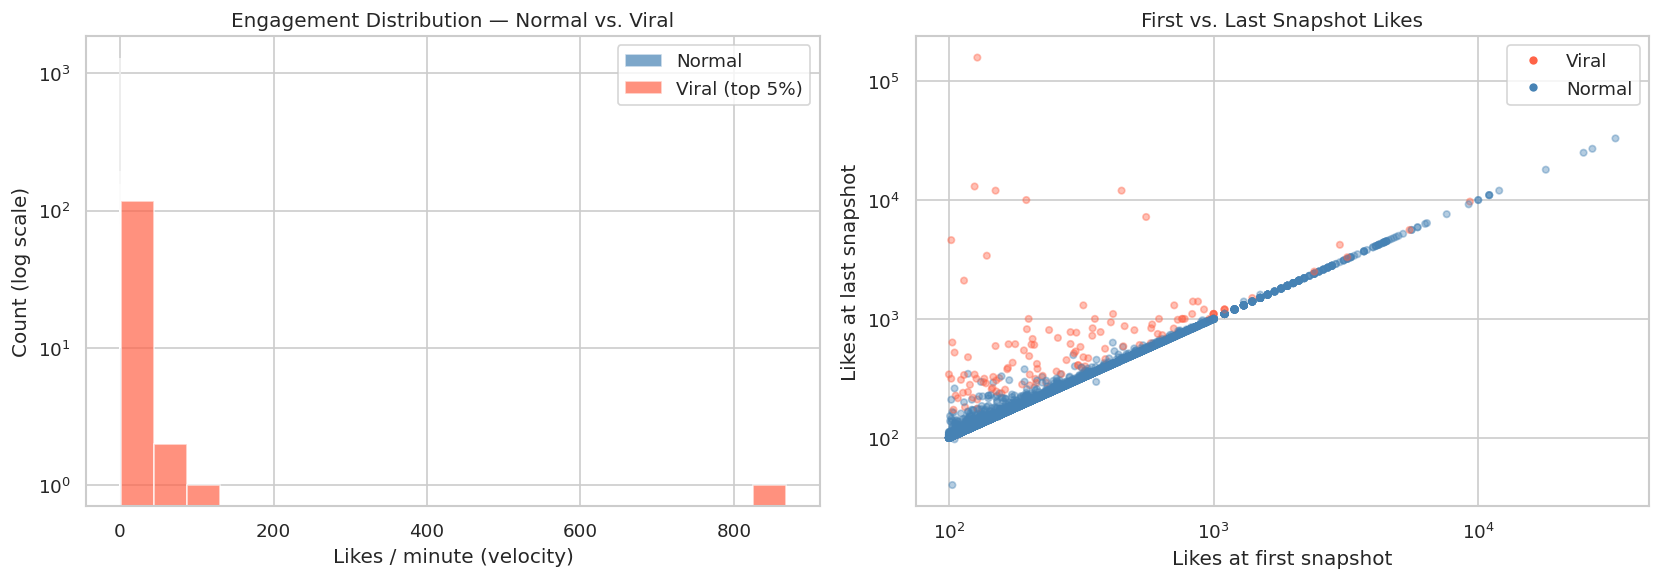

In [241]:
# ---------------------------------------------------------------------------
# Step 2: Visualise engagement distribution — normal vs. viral tweets
# ---------------------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: histogram of the primary viral metric
ax = axes[0]
normal = engagement.loc[~engagement["is_viral"], viral_metric].dropna()
viral  = engagement.loc[ engagement["is_viral"],  viral_metric].dropna()
ax.hist(normal, bins=50, alpha=0.7, label="Normal", color="steelblue", log=True)
ax.hist(viral,  bins=20, alpha=0.7, label="Viral (top 5%)", color="tomato", log=True)
ax.set_xlabel(viral_label)
ax.set_ylabel("Count (log scale)")
ax.set_title("Engagement Distribution — Normal vs. Viral")
ax.legend()

# Right: scatter — first_likes vs. last_likes coloured by viral flag
ax2 = axes[1]
scatter = ax2.scatter(
    engagement["first_likes"],
    engagement["last_likes"],
    c=engagement["is_viral"].map({True: "tomato", False: "steelblue"}),
    alpha=0.4, s=15,
)
ax2.set_xscale("log"); ax2.set_yscale("log")
ax2.set_xlabel("Likes at first snapshot")
ax2.set_ylabel("Likes at last snapshot")
ax2.set_title("First vs. Last Snapshot Likes")
handles = [
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="tomato",    label="Viral"),
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="steelblue", label="Normal"),
]
ax2.legend(handles=handles)

plt.tight_layout()
plt.show()

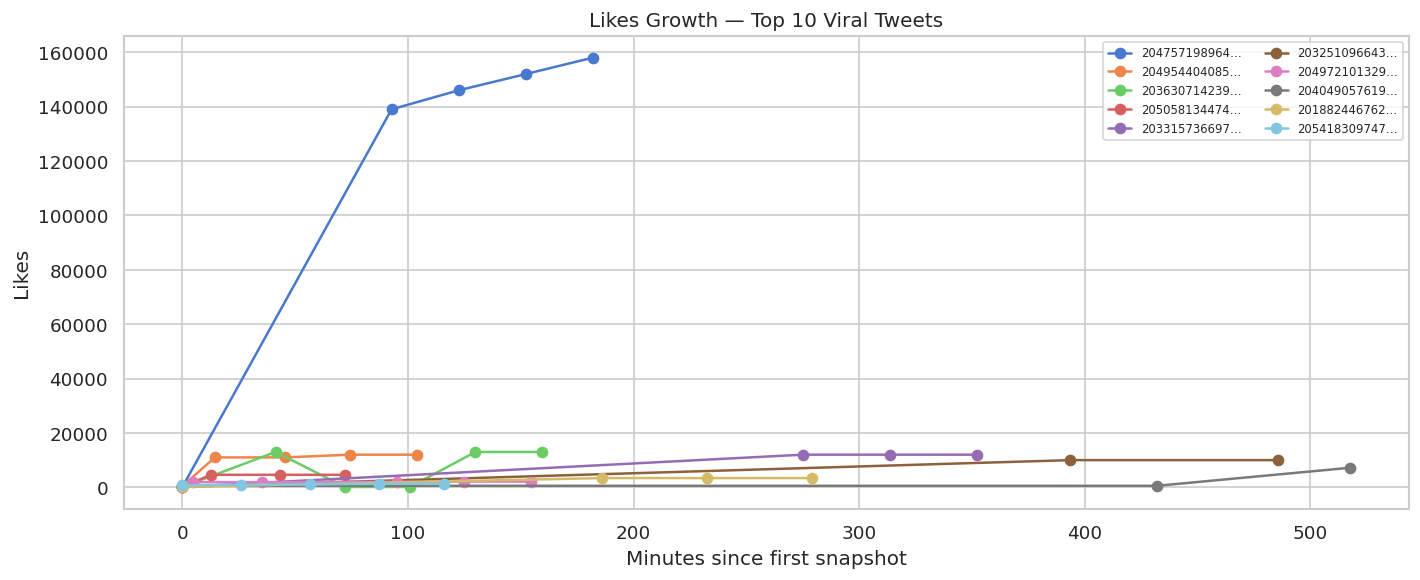

In [242]:
# ---------------------------------------------------------------------------
# Step 3: Velocity timeline (only meaningful when multi-snapshot data exists)
# Shows the engagement growth curve for the top-10 most viral tweets.
# ---------------------------------------------------------------------------

top_viral_ids = (
    engagement[engagement["is_viral"]]
    .nlargest(10, viral_metric)["tweet_id"]
    .tolist()
)

if engagement["snap_count"].max() > 1:
    fig, ax = plt.subplots(figsize=(12, 5))
    for tid in top_viral_ids:
        ts = snaps[snaps["tweet_id"] == tid].sort_values("crawled_at")
        t0 = ts["crawled_at"].iloc[0]
        ts = ts.assign(minutes_since_post=(ts["crawled_at"] - t0).dt.total_seconds() / 60)
        ax.plot(ts["minutes_since_post"], ts["likes"], marker="o", linewidth=1.5,
                label=tid[:12] + "…")
    ax.set_xlabel("Minutes since first snapshot")
    ax.set_ylabel("Likes")
    ax.set_title("Likes Growth — Top 10 Viral Tweets")
    ax.legend(fontsize=7, ncol=2)
    plt.tight_layout()
    plt.show()
else:
    print("No multi-snapshot data available yet — velocity timeline will appear once")
    print("the crawler has been running for at least one full 2-hour poll cycle.")
    print()
    print("Top 10 tweets by absolute engagement (first snapshot):")
    print(
        engagement.nlargest(10, "total_engagement_first")
        [["tweet_id", "first_likes", "first_retweets", "total_engagement_first"]]
        .to_string(index=False)
    )

## 12 — Viral Tweets & Price Reaction

Top-**3 viral tweets per Focus Ticker** (by metric from Section 11) joined with their **±3 trading day price window**.
This ensures every company of interest is represented.

| Column | Meaning |
|--------|---------|
| **Close T-3 / T0 / T+3** | Adjusted Close 3 trading days before / on / 3 trading days after the tweet |
| **Ret T-3→T0 %** | Return from T-3 to tweet day — green = positive, red = negative |
| **Ret T0→T+3 %** | Return from tweet day to T+3 — green = positive, red = negative |

Only **Focus Tickers** (from `configs/tickers.yml`) with price data are included.
Tweets without matching price data show "—".


In [243]:

# ---------------------------------------------------------------------------
# Build viral_tweets: join engagement with metadata, assign each tweet to a
# Focus Ticker via TICKER_META (same two-pass logic as Section 2.5), compute
# ±3 trading day price window per tweet, and produce viral_table.
#
# Why TICKER_META instead of raw `symbol`:
#   The DB stores raw cashtags (BYD, VOW, ENI …) which don't match the
#   yfinance FOCUS_TICKER symbols (BYDDY, VWAGY, E …). Keyword-match on
#   content covers the NULL-symbol tweets from hashtag queries.
#
# Strategy: top-3 by engagement per Focus Ticker → every company represented.
# ---------------------------------------------------------------------------

from IPython.display import display

trading_days_list = trading_days.normalize()   # tz-naive DatetimeIndex

TOP_N_PER_TICKER = 3


def _window_prices(ticker: str, posted) -> tuple:
    """Return (close_tm3, close_t0, close_tp3) for a tweet.

    T0  = nearest NYSE trading day on or after the tweet date.
    T-3 / T+3 = 3 NYSE sessions before / after T0.
    Returns (None, None, None) when no price data is available.
    """
    posted_naive = posted.tz_localize(None) if posted.tzinfo else posted
    posted_norm  = posted_naive.normalize()

    future_td = trading_days_list[trading_days_list >= posted_norm]
    if future_td.empty:
        return None, None, None
    t0_td = future_td[0]

    t0_idx   = trading_days_list.get_loc(t0_td)
    tm3_date = trading_days_list[max(0, t0_idx - 3)]
    tp3_date = trading_days_list[min(len(trading_days_list) - 1, t0_idx + 3)]

    p = prices_sorted[prices_sorted["Ticker"] == ticker].copy()
    p["Date_norm"] = p["Date"].dt.normalize()

    def _close(d):
        row = p[p["Date_norm"] == d]
        return float(row["Adj Close"].iloc[0]) if not row.empty else None

    return _close(tm3_date), _close(t0_td), _close(tp3_date)


# ---------------------------------------------------------------------------
# Step 1 — Assign each tweet a focus_ticker via TICKER_META (two-pass).
# Same logic as Section 2.5 but applied at tweet level.
# ---------------------------------------------------------------------------
price_ticker_set = set(prices["Ticker"].unique())
_content = tweets["content"].fillna("")
_has_sym  = tweets["symbol"].notna()

focus_ticker_col: list[str | None] = [None] * len(tweets)

for focus_t in FOCUS_TICKERS:
    if focus_t not in price_ticker_set:
        continue
    meta    = TICKER_META.get(focus_t, {"symbol_aliases": [focus_t], "keyword_re": None})
    aliases = meta["symbol_aliases"]
    kw_re   = meta["keyword_re"]

    # Pass 1: symbol alias match
    if aliases:
        sym_hit = tweets["symbol"].isin(aliases)
        for idx in tweets.index[sym_hit]:
            if focus_ticker_col[idx] is None:
                focus_ticker_col[idx] = focus_t

    # Pass 2: keyword match on NULL-symbol rows that are still unassigned
    if kw_re is not None:
        unassigned_no_sym = ~_has_sym & pd.Series(
            [focus_ticker_col[i] is None for i in range(len(tweets))],
            index=tweets.index,
        )
        kw_hit = unassigned_no_sym & _content.map(lambda x, r=kw_re: bool(r.search(x)))
        for idx in tweets.index[kw_hit]:
            focus_ticker_col[idx] = focus_t

tweets["focus_ticker"] = focus_ticker_col

# ---------------------------------------------------------------------------
# Step 2 — Join with engagement, keep only Focus Tickers with price data.
# ---------------------------------------------------------------------------
all_with_engagement = (
    engagement
    .merge(
        tweets[["tweet_id", "posted_at", "symbol", "focus_ticker", "content", "author"]],
        on="tweet_id",
        how="inner",
    )
)

all_with_engagement = all_with_engagement[
    all_with_engagement["focus_ticker"].notna()
    & all_with_engagement["focus_ticker"].isin(price_ticker_set)
]

# Top-3 per ticker by viral_metric
viral_tweets = (
    all_with_engagement
    .sort_values(viral_metric, ascending=False)
    .groupby("focus_ticker", sort=False)
    .head(TOP_N_PER_TICKER)
    .sort_values(["focus_ticker", viral_metric], ascending=[True, False])
    .reset_index(drop=True)
)

tickers_covered = viral_tweets["focus_ticker"].nunique()
print(f"Focus Tickers covered: {tickers_covered} / {len(FOCUS_TICKERS)}")
print(f"Total rows in table:   {len(viral_tweets)} (max {TOP_N_PER_TICKER} per ticker)")

# ---------------------------------------------------------------------------
# Step 3 — Compute price windows and build viral_table.
# ---------------------------------------------------------------------------
if not viral_tweets.empty:
    rows = []
    rank = 1
    for _, row in viral_tweets.iterrows():
        ticker = row["focus_ticker"]
        tm3, t0, tp3 = _window_prices(ticker, row["posted_at"])
        posted_naive = row["posted_at"].tz_localize(None) if row["posted_at"].tzinfo else row["posted_at"]
        content_str  = str(row["content"] or "")
        tweet_short  = (content_str[:80] + "…") if len(content_str) > 80 else content_str
        rows.append({
            "#":             rank,
            "Ticker":        ticker,
            "Author":        f"@{row['author']}",
            "Posted at":     posted_naive.strftime("%Y-%m-%d %H:%M"),
            "Tweet":         tweet_short,
            "Viral Score":   round(row[viral_metric], 2),
            "Close T-3":     round(tm3, 2) if tm3 is not None else None,
            "Close T0":      round(t0,  2) if t0  is not None else None,
            "Close T+3":     round(tp3, 2) if tp3 is not None else None,
            "Ret T-3→T0 %":  round((t0 / tm3 - 1) * 100, 2) if tm3 and t0 else None,
            "Ret T0→T+3 %":  round((tp3 / t0 - 1) * 100, 2) if t0 and tp3 else None,
        })
        rank += 1
    viral_table = pd.DataFrame(rows).set_index("#")
else:
    viral_table = pd.DataFrame()
    print("No tweets found for Focus Tickers — section skipped.")


Focus Tickers covered: 12 / 12
Total rows in table:   36 (max 3 per ticker)


In [244]:
# ---------------------------------------------------------------------------
# Display viral_table as a styled DataFrame.
# Return columns are color-coded: green = positive, red = negative.
# ---------------------------------------------------------------------------

if not viral_table.empty:

    def _color_ret(val):
        """Apply green/red background to return columns."""
        if pd.isna(val):
            return ""
        return "background-color: #d4edda" if val >= 0 else "background-color: #f8d7da"

    ret_cols = ["Ret T-3→T0 %", "Ret T0→T+3 %"]

    styled = (
        viral_table.style
        .format({
            "Viral Score":   "{:.2f}",
            "Close T-3":     "{:.2f}",
            "Close T0":      "{:.2f}",
            "Close T+3":     "{:.2f}",
            "Ret T-3→T0 %":  "{:+.2f}",
            "Ret T0→T+3 %":  "{:+.2f}",
        }, na_rep="—")
        .map(_color_ret, subset=ret_cols)
        .set_properties(**{"text-align": "left", "white-space": "pre-wrap"})
        .set_table_styles([
            {"selector": "th", "props": [("text-align", "left"), ("font-weight", "bold")]},
            {"selector": "td", "props": [("vertical-align", "top")]},
        ])
    )

    print(f"Top {len(viral_table)} viral tweets — Focus Tickers — ±3 trading days")
    print(f"Viral metric: {viral_metric}")
    display(styled)


Top 36 viral tweets — Focus Tickers — ±3 trading days
Viral metric: velocity_likes_per_min


,Ticker,Author,Posted at,Tweet,Viral Score,Close T-3,Close T0,Close T+3,Ret T-3→T0 %,Ret T0→T+3 %
#,,,,,,,,,,
1,6367.T,@pichonkun_photo,2026-03-18 00:39,"Today's congratulatory message comes from JR West Japan's transport IC card ""ICO…",—,18893.23,19612.07,18471.83,+3.80,-5.81
2,6367.T,@pichonkun_photo,2026-03-19 00:00,"Today's congratulatory message comes from ""Buffalo Blue Buffalo Bell"" of the Ori…",—,18739.54,19205.55,19185.72,+2.49,-0.10
3,6367.T,@Orix_Buffaloes,2026-03-19 01:00,／ ダイキンの空気の看板 「大ぴちょんくん」10周年おめでとう！／ ＼ 球場のバックネット裏広告看板でおなじみのダイキンのぴちょんくん バファローブル・バファ…,—,18739.54,19205.55,19185.72,+2.49,-0.10
4,6503.T,@TamilNaduInfra,2026-02-06 09:04,CM MK Stalin today inaugurated the air conditioner & compressor manufacturing pl…,0.00,4971.88,5448.19,—,+9.58,—
5,6503.T,@koalas_1956,2026-01-02 00:00,新年明けましておめでとうございます 本年も三菱電機コアラーズをよろしくお願いいたします #三菱電機 #コアラーズ,—,4593.03,—,4773.01,—,—
6,6503.T,@nagoyadolphins,2026-01-02 00:53,よろしくお願いいたします ともに、シーズンを駆け抜けましょう #三菱電機 #コアラーズ #ドルフィンズ,—,4593.03,—,4773.01,—,—
7,BP,@wolfofshib8,2026-05-04 23:08,@BarkingPuppy8 Keith said; I like the Stocks … he gonna say soon; I like $BP,4.01,—,—,—,—,—
8,BP,@BarkingPuppy8,2026-04-29 12:12,Well I have a cult like following in $BP however AMC is seems to gaining tract…,0.56,—,—,—,—,—
9,BP,@Havochl_,2026-05-07 10:01,If you traded on @Backpack in 2024 and did $10M volume you got ~$520 via $BP …,0.27,—,—,—,—,—
